In [10]:
library(ggplot2)
library(edgeR)
library(igraph)
library(SingleCellExperiment)
library(scran)
library(scater)
library(irlba)
#library(ggthemes)
library(ggsci)
#library(cydar)
#library(mvtnorm)
library(uwot)
library(reshape2)
library(data.table)


Attaching package: ‘data.table’


The following objects are masked from ‘package:reshape2’:

    dcast, melt


The following object is masked from ‘package:SummarizedExperiment’:

    shift


The following object is masked from ‘package:GenomicRanges’:

    shift


The following object is masked from ‘package:IRanges’:

    shift


The following objects are masked from ‘package:S4Vectors’:

    first, second




In [85]:
library(miloR)
library(SingleCellExperiment)
library(scater)
library(scran)
library(dplyr)
library(patchwork)


Attaching package: ‘miloR’


The following object is masked from ‘package:igraph’:

    graph



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:igraph’:

    as_data_frame, groups, union


The following objects are masked from ‘packa

In [86]:
library(MouseGastrulationData)

ERROR: Error in library(MouseGastrulationData): there is no package called ‘MouseGastrulationData’


In [56]:
sim1.pca = fread("/rds/project/rds-SDzz0CATGms/users/bt392/06_Runx1_RNA/results/rna/dimensionality_reduction/test/pca_features1000_pcs30_batchcorrectionbysample.txt.gz")
meta = fread("/rds/project/rds-SDzz0CATGms/users/bt392/06_Runx1_RNA/results/rna/mapping/sample_metadata_after_mapping.txt.gz")

In [58]:
cells = sim1.pca[,1]
sim1.pca = sim1.pca[,-1]
meta = meta[cell %in% cells$cell, c('sample', 'celltype.mapped_mnn')]

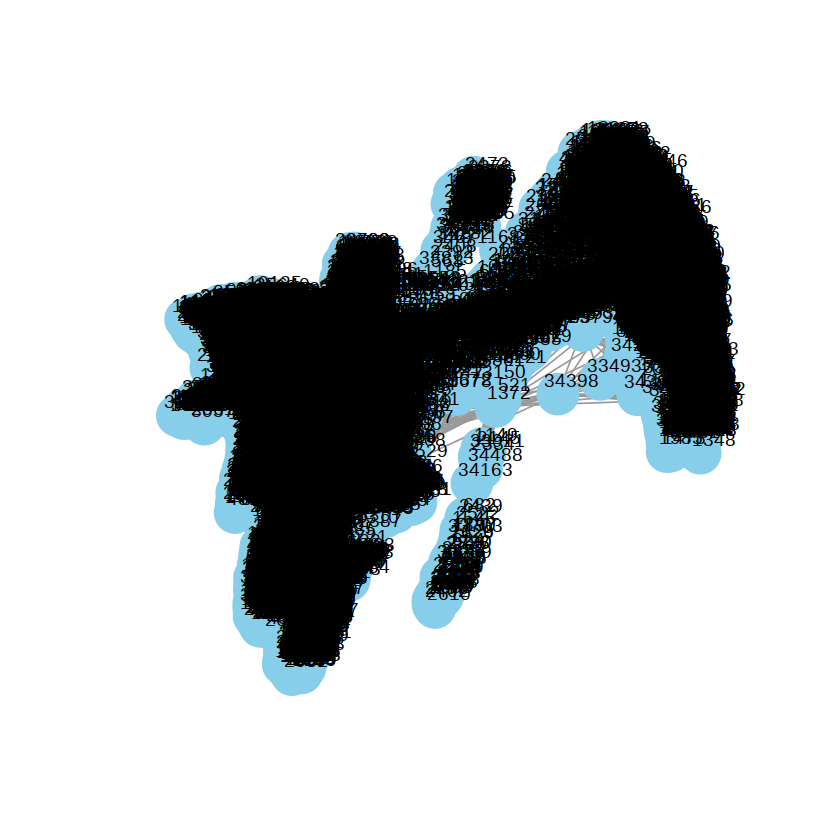

In [36]:
sim1.knn <- buildKNNGraph(x=as.matrix(sim1.pca), k=21, d=NA, transposed=TRUE)
sim1.fr.layout <- layout_with_fr(sim1.knn)
plot(sim1.knn, layout=sim1.fr.layout, vertex.frame.color='skyblue', vertex.color='skyblue', vertex.label.color='black', 
     vertex.label.family='Helvetica', edge.color='grey60', vertex.label.cex=0.9,
     vertex.label.dist=1, edge.arrow.size=0.2)

In [38]:
set.seed(42)
stem.ta.umap <- umap(as.vector(sim1.pca),
                     n_components=2,
                     n_neighbors=21, metric='euclidean',
                     init='random', min_dist=0.1)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'plot': $ operator is invalid for atomic vectors


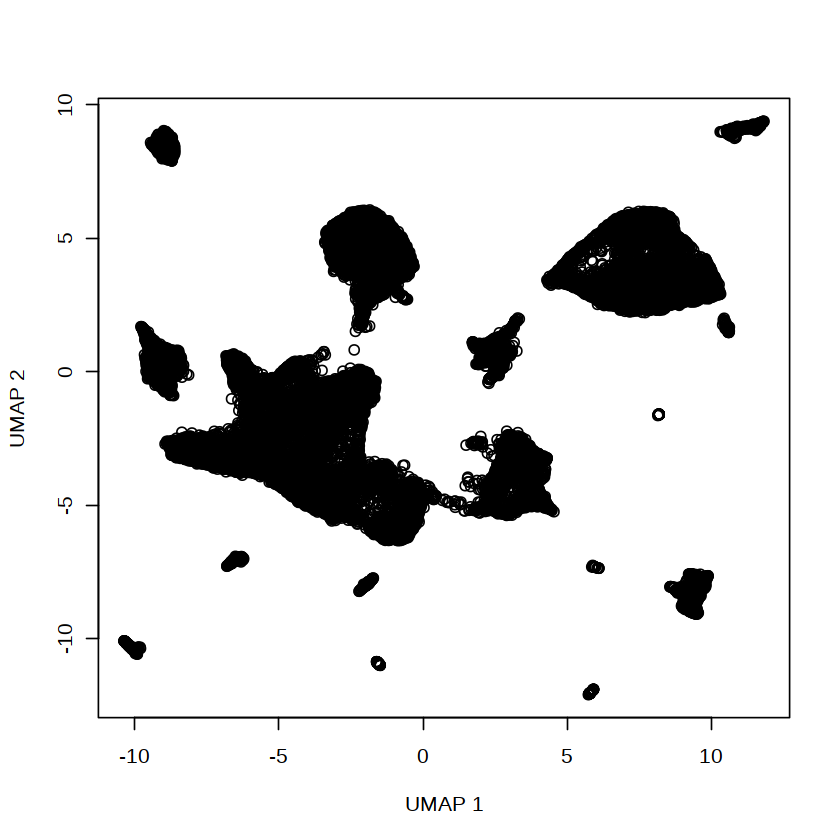

In [40]:
plot(stem.ta.umap,
     xlab="UMAP 1", ylab="UMAP 2")

In [75]:
meta.df <- cbind(meta, stem.ta.umap)
meta.df$condition = c(rep('A', 10000), rep('B', 10000), rep('C', nrow(meta.df)-20000))
colnames(meta.df) <- c("Block", "Replicate", "UMAP1", "UMAP2", 'Condition')
meta.df <- meta.df[,c("Block", "Condition", "Replicate", "UMAP1", "UMAP2")]

In [76]:
head(meta.df)

Block,Condition,Replicate,UMAP1,UMAP2
<chr>,<chr>,<chr>,<dbl>,<dbl>
SLX-21184_SITTA7_H5NKNDMXY,A,Erythroid3,9.032687,4.741852
SLX-21184_SITTA7_H5NKNDMXY,A,Erythroid2,8.897925,3.001755
SLX-21184_SITTA7_H5NKNDMXY,A,Surface_ectoderm,-6.722795,-7.213434
SLX-21184_SITTA7_H5NKNDMXY,A,Erythroid3,9.660029,3.381907
SLX-21184_SITTA7_H5NKNDMXY,A,ExE_ectoderm,8.149997,-1.643130
SLX-21184_SITTA7_H5NKNDMXY,A,Erythroid3,9.876529,2.981345


In [77]:
meta.df$Sample <- paste(meta.df$Condition, meta.df$Block, sep="_")
meta.df$Vertex <- c(1:nrow(meta.df))

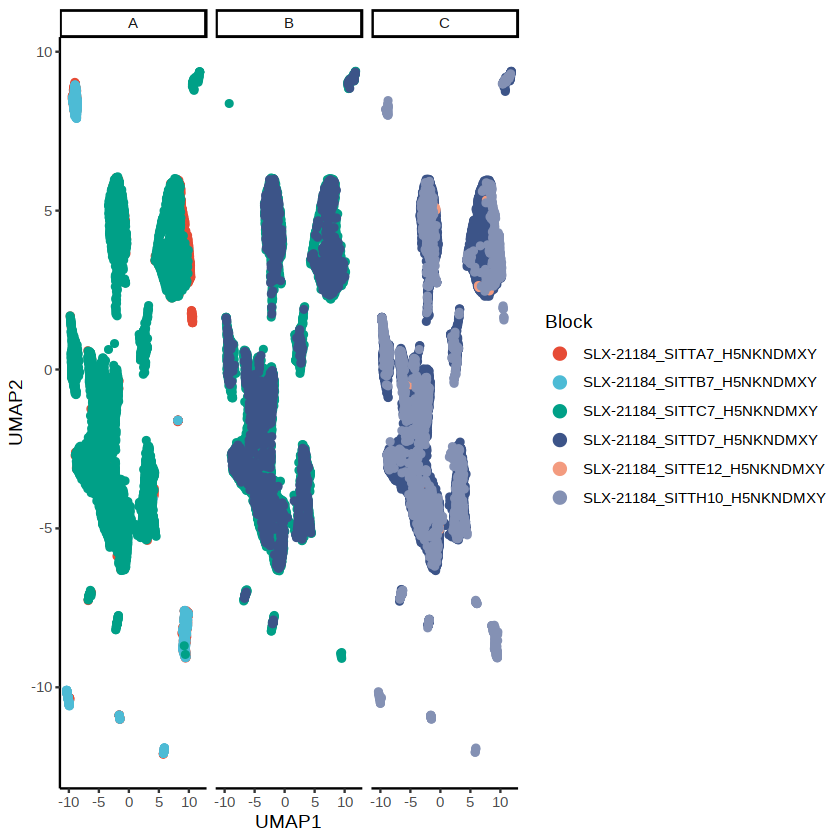

In [78]:
ggplot(meta.df, aes(x=UMAP1, y=UMAP2)) +
  geom_point(aes(colour=Block)) +
  theme_classic() + 
  scale_colour_npg() +
  facet_wrap(~Condition) +
  guides(colour=guide_legend(override.aes=list(size=3)),
         shape=guide_legend(override.aes=list(size=3)))

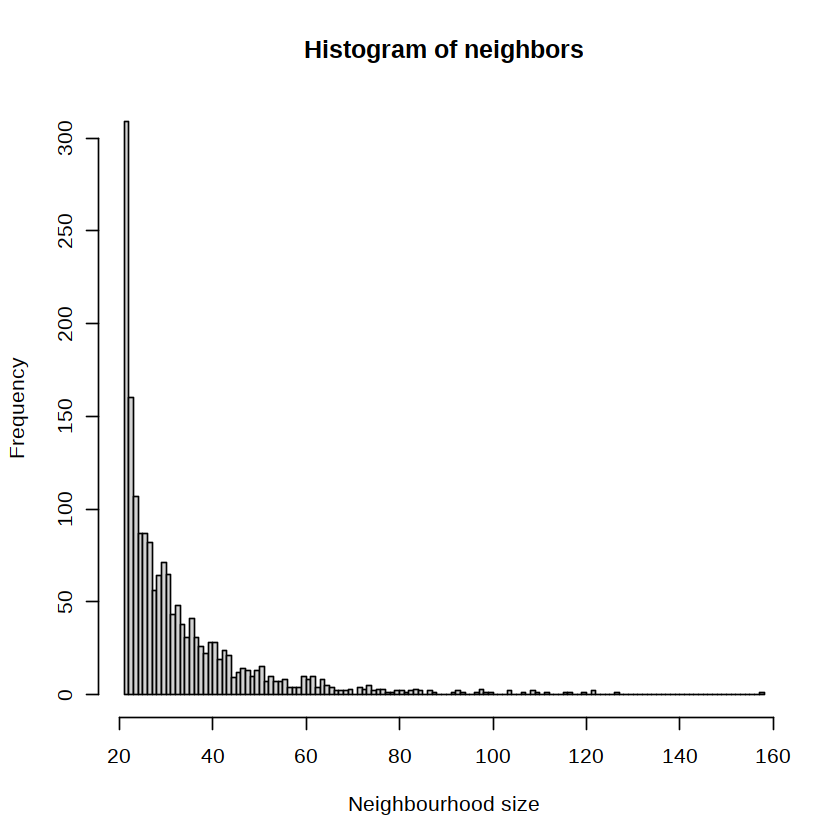

In [79]:
# randomly select vertices in the graph
n.hood <- 0.05
random.vertices <- sample(V(sim1.knn), size=floor(n.hood*length(V(sim1.knn))))
# loop over random vertices and count the number of cells in each
vertex.list <- sapply(1:length(random.vertices), FUN=function(X) neighbors(sim1.knn, v=random.vertices[X]))
hist(unlist(lapply(vertex.list, length)), 100, main="Histogram of neighbors", xlab="Neighbourhood size")

In [82]:
quant_neighbourhood <- function(graph, meta, sample.column='Sample', sample.vertices=0.25, seed=42){
  set.seed(seed)
  # define a set of vertices and neihbourhood centers - extract the neihbourhoods of these cells
  random.vertices <- sample(V(graph), size=floor(sample.vertices*length(V(graph))))
  vertex.list <- sapply(1:length(random.vertices), FUN=function(X) neighbors(graph, v=random.vertices[X]))
  
  count.matrix <- matrix(0L, ncol=length(unique(meta[, sample.column])), nrow=length(vertex.list))
  colnames(count.matrix) <- unique(meta[, sample.column])
  
  for(x in seq_along(1:length(vertex.list))){
    v.x <- vertex.list[[x]]
    for(i in seq_along(1:length(unique(meta[, sample.column])))){
      i.s <- unique(meta[, sample.column])[i]
      i.s.vertices <- intersect(v.x, meta[meta[, sample.column] == i.s, ]$Vertex)
      count.matrix[x, i] <- length(i.s.vertices)
    }
  }
  rownames(count.matrix) <- c(1:length(vertex.list))
  return(count.matrix)
}

In [84]:
sim1.counts <- quant_neighbourhood(graph=sim1.knn, meta=meta.df, sample.column='Sample', sample.vertices=n.hood)
sample.meta <- data.frame("Condition"=c(rep("A", 3), rep("B", 3)),
                          "Replicate"=rep(c("R1", "R2", "R3"), 2))
sample.meta$Sample <- paste(sample.meta$Condition, sample.meta$Replicate, sep="_")
rownames(sample.meta) <- sample.meta$Sample
# sim1.model <- model.matrix(~ 0 + Condition, data=sample.meta)
sim1.model <- model.matrix(~ Condition, data=sample.meta)
head(sim1.model)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'unique': j (the 2nd argument inside [...]) is a single symbol but column name 'sample.column' is not found. Perhaps you intended DT[, ..sample.column]. This difference to data.frame is deliberate and explained in FAQ 1.1.


In [83]:
# define a set of vertices and neihbourhood centers - extract the neihbourhoods of these cells
set.seed(42)
random.vertices <- sample(V(sim1.knn), size=floor(n.hood*length(V(sim1.knn))))
vertex.list <- sapply(1:length(random.vertices), FUN=function(X) neighbors(sim1.knn, v=random.vertices[X]))

count.matrix <- matrix(0L, ncol=length(unique(meta.df[, "Sample"])), nrow=length(vertex.list))
colnames(count.matrix) <- unique(meta.df[, "Sample"])

for(x in seq_along(1:length(vertex.list))){
  v.x <- vertex.list[[x]]
  for(i in seq_along(1:length(unique(meta.df[, "Sample"])))){
    i.s <- unique(meta.df[, "Sample"])[i]
    i.s.vertices <- intersect(v.x, meta.df[meta.df[, "Sample"] == i.s, ]$Vertex)
    count.matrix[x, i] <- length(i.s.vertices)
  }
}
rownames(count.matrix) <- c(1:length(vertex.list))

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'y' in selecting a method for function 'intersect': ‘==’ only defined for equally-sized data frames


In [ ]:

set.seed(42)
block1.cond <- rep("A", block1.cells)
block1.a <- sample(1:block1.cells, size=floor(block1.cells*0.9))
block1.b <- setdiff(1:block1.cells, block1.a)
block1.cond[block1.b] <- "B"

block2.cond <- rep("A", block2.cells)
block2.a <- sample(1:block2.cells, size=floor(block2.cells*0.05))
block2.b <- setdiff(1:block2.cells, block2.a)
block2.cond[block2.b] <- "B"

block3.cond <- rep("A", block3.cells)
block3.a <- sample(1:block3.cells, size=floor(block3.cells*0.5))
block3.b <- setdiff(1:block3.cells, block3.a)
block3.cond[block3.b] <- "B"

meta.df <- data.frame("Block"=c(rep("B1", block1.cells), rep("B2", block2.cells), rep("B3", block3.cells)),
                      "Condition"=c(block1.cond, block2.cond, block3.cond),
                      "Replicate"=c(rep("R1", floor(block1.cells*0.33)), rep("R2", floor(block1.cells*0.33)), 
                                    rep("R3", block1.cells-(2*floor(block1.cells*0.33))),
                                    rep("R1", floor(block2.cells*0.33)), rep("R2", floor(block2.cells*0.33)), 
                                    rep("R3", block2.cells-(2*floor(block2.cells*0.33))),
                                    rep("R1", floor(block3.cells*0.33)), rep("R2", floor(block3.cells*0.33)), 
                                    rep("R3", block3.cells-(2*floor(block3.cells*0.33)))))
meta.df <- cbind(meta.df, stem.ta.umap$layout)
colnames(meta.df) <- c("Block", "Condition", "Replicate", "UMAP1", "UMAP2")
# define a "sample" as teh combination of condition and replicate
meta.df$Sample <- paste(meta.df$Condition, meta.df$Replicate, sep="_")
meta.df$Vertex <- c(1:nrow(meta.df))
```


```{r}
ggplot(meta.df, aes(x=UMAP1, y=UMAP2)) +
  geom_point(aes(colour=Block, shape=Replicate)) +
  theme_clean() +
  scale_colour_npg() +
  facet_wrap(~Condition) +
  guides(colour=guide_legend(override.aes=list(size=3)),
         shape=guide_legend(override.aes=list(size=3)))
```

Using these simulated data we can define lots of neighbourhoods across the graph to create a counts matrix of neighbourhoods vs conditions 
in a similar way as `cydar`. I'll start with random vertices in the graph making up 5% of all points and extract the graph neighborhoods.

```{r}
# randomly select vertices in the graph
n.hood <- 0.05
random.vertices <- sample(V(sim1.knn), size=floor(n.hood*length(V(sim1.knn))))
# loop over random vertices and count the number of cells in each
vertex.list <- sapply(1:length(random.vertices), FUN=function(X) neighbors(sim1.knn, v=random.vertices[X]))
hist(unlist(lapply(vertex.list, length)), 100, main="Histogram of neighbors", xlab="Neighbourhood size")
```

For each neighbourhood I'll count the number of cells in each, determined by the experimental design, i.e. replicate, condition and block.

```{r}
quant_neighbourhood <- function(graph, meta, sample.column='Sample', sample.vertices=0.25, seed=42){
  set.seed(seed)
  # define a set of vertices and neihbourhood centers - extract the neihbourhoods of these cells
  random.vertices <- sample(V(graph), size=floor(sample.vertices*length(V(graph))))
  vertex.list <- sapply(1:length(random.vertices), FUN=function(X) neighbors(graph, v=random.vertices[X]))
  
  count.matrix <- matrix(0L, ncol=length(unique(meta[, sample.column])), nrow=length(vertex.list))
  colnames(count.matrix) <- unique(meta[, sample.column])
  
  for(x in seq_along(1:length(vertex.list))){
    v.x <- vertex.list[[x]]
    for(i in seq_along(1:length(unique(meta[, sample.column])))){
      i.s <- unique(meta[, sample.column])[i]
      i.s.vertices <- intersect(v.x, meta[meta[, sample.column] == i.s, ]$Vertex)
      count.matrix[x, i] <- length(i.s.vertices)
    }
  }
  rownames(count.matrix) <- c(1:length(vertex.list))
  return(count.matrix)
}
```


```{r}
# define a set of vertices and neihbourhood centers - extract the neihbourhoods of these cells
set.seed(42)
random.vertices <- sample(V(sim1.knn), size=floor(n.hood*length(V(sim1.knn))))
vertex.list <- sapply(1:length(random.vertices), FUN=function(X) neighbors(sim1.knn, v=random.vertices[X]))

count.matrix <- matrix(0L, ncol=length(unique(meta.df[, "Sample"])), nrow=length(vertex.list))
colnames(count.matrix) <- unique(meta.df[, "Sample"])

for(x in seq_along(1:length(vertex.list))){
  v.x <- vertex.list[[x]]
  for(i in seq_along(1:length(unique(meta.df[, "Sample"])))){
    i.s <- unique(meta.df[, "Sample"])[i]
    i.s.vertices <- intersect(v.x, meta.df[meta.df[, "Sample"] == i.s, ]$Vertex)
    count.matrix[x, i] <- length(i.s.vertices)
  }
}
rownames(count.matrix) <- c(1:length(vertex.list))
```


```{r}
sim1.counts <- quant_neighbourhood(graph=sim1.knn, meta=meta.df, sample.column='Sample', sample.vertices=n.hood)
sample.meta <- data.frame("Condition"=c(rep("A", 3), rep("B", 3)),
                          "Replicate"=rep(c("R1", "R2", "R3"), 2))
sample.meta$Sample <- paste(sample.meta$Condition, sample.meta$Replicate, sep="_")
rownames(sample.meta) <- sample.meta$Sample
# sim1.model <- model.matrix(~ 0 + Condition, data=sample.meta)
sim1.model <- model.matrix(~ Condition, data=sample.meta)
head(sim1.model)
```

I have a model matrix and counts matrix - let's test edgeR on these.

```{r}
sim1.dge <- DGEList(sim1.counts[, rownames(sim1.model)], lib.size=log(colSums(sim1.counts[, rownames(sim1.model)])))
sim1.dge <- estimateDisp(sim1.dge, sim1.model)
sim1.fit <- glmQLFit(sim1.dge, sim1.model, robust=TRUE)
# sim1.contrast <- makeContrasts(ConditionA - ConditionB, levels=sim1.model)
# sim1.res <- glmQLFTest(sim1.fit, contrast=sim1.contrast)

sim1.res <- as.data.frame(topTags(glmQLFTest(sim1.fit, coef=2), sort.by='none', n=Inf))
sim1.res$Sig <- as.factor(as.numeric(sim1.res$FDR <= 0.01))
sim1.res$Neighbourhood <- as.numeric(rownames(sim1.res))

# control the spatial FDR
qvals <- sim1.res$PValue
is.sig <- qvals <= 0.01
summary(is.sig)
```

This indicates that 123 of the neighbour hoods are significant before spatial FDR correction. The implementation in `Cydar` relies on having the 
median marker intensities for each hypersphere. What is the equivalent positional information here? What about drawing a new graph for each 
neighborhood using the `igraph::induced_subgraph` function, then calculate the connectivity of this new sub-graph as a measure of the 
neighborhood density?

```{r}
# this creates a sub-graph for each of the random vertices
test.subgraphs <- lapply(1:length(random.vertices),
                         FUN=function(X) induced_subgraph(sim1.knn, vertex.list[[X]]))

# now loop over these sub-graphs to calculate the connectivity - this seems a little slow...
test.connect <- lapply(test.subgraphs, FUN=function(EG) vertex_connectivity(EG))
```

Vertex connectivity is slow to compute - edge connectivity might be faster and has the useful property that:

$$k(G) \leq \lambda(G) $$
That is, the vertex connectivity $k(G)$ is $\leq$ than the edge connectivity $\lambda(G)$. In this instance the edge-connectivity is an 
upper-bound on the neighborhood connectivity, and thus an upper bound on the density, leading to a slightly lower weighting for the spatial FDR 
adjustment.

```{r}
# now loop over these sub-graphs to calculate the connectivity - this seems a little slow...
edge.connect <- lapply(test.subgraphs, FUN=function(EG) edge_connectivity(EG))
```

The edge-connectivity takes ~10% of the time. How do they compare?

```{r}
plot(unlist(test.connect), unlist(edge.connect), main="Graph-connectivity measures", xlab="Vertex-connectivity", ylab="Edge-connectivity")
```

For the most part the vertex-connectivity and edge-connectivity for neighborhoods are in pretty good agreement. I'll maybe include the option 
to use either as a function parameter.

```{r}
graph_spatialFDR <- function(neighborhoods, graph, pvalues, connectivity='vertex'){
  # input a set of neighborhoods as a list of graph vertices
  # the input graph and the unadjusted GLM p-values
  #' neighborhoods: list of vertices and their respective neighborhoods
  #' graph: input kNN graph
  #' pvalues: a vector of pvalues in the same order as the neighborhood indices
  #' connectivity: character - edge or vertex to calculate neighborhood connectivity

  # Discarding NA pvalues.
  haspval <- !is.na(pvalues)
  if (!all(haspval)) {
      coords <- coords[haspval, , drop=FALSE]
      pvalues <- pvalues[haspval]
  }
    
  # define the subgraph for each neighborhood then calculate the vertex connectivity for each
  # this latter computation is quite slow - can it be sped up?
  subgraphs <- lapply(1:length(neighborhoods[haspval]),
                         FUN=function(X) induced_subgraph(graph, neighborhoods[haspval][[X]]))

  # now loop over these sub-graphs to calculate the connectivity - this seems a little slow...
  if(connectivity == "vertex"){
    connect <- lapply(subgraphs, FUN=function(EG) vertex_connectivity(EG))
  } else if(connectivity == "edge"){
    connect <- lapply(subgraphs, FUN=function(EG) edge_connectivity(EG))
  } else{
    stop("connectivity option not recognised - must be either edge or vertex")
  }
  
  # use 1/connectivity as the weighting for the weighted BH adjustment from Cydar
  w <- 1/unlist(connect)
  # set Inf to 0
  w[is.infinite(w)] <- 0
  
  # Computing a density-weighted q-value.
  o <- order(pvalues)
  pvalues <- pvalues[o]
  w <- w[o]

  adjp <- numeric(length(o))
  adjp[o] <- rev(cummin(rev(sum(w)*pvalues/cumsum(w))))
  adjp <- pmin(adjp, 1)

  if (!all(haspval)) {
    refp <- rep(NA_real_, length(haspval))
    refp[haspval] <- adjp
    adjp <- refp
    }
  return(adjp)
}
```


```{r}
start.time <- Sys.time()
sim1.spatialfdr <- graph_spatialFDR(neighborhoods=vertex.list, graph=sim1.knn, connectivity="edge",
                                    pvalues=sim1.res[order(sim1.res$Neighbourhood), ]$PValue)
end.time <- Sys.time()
connect.time <- end.time - start.time
sim1.res$SpatialFDR[order(sim1.res$Neighbourhood)] <- sim1.spatialfdr
qvals <- sim1.spatialfdr
is.sig <- qvals <= 0.01
summary(is.sig)
```

How do these compare to the standard FDR adjustment?

```{r}
plot(-log10(sim1.res[order(sim1.res$Neighbourhood), ]$FDR),
     -log10(sim1.spatialfdr), main="FDR comparison", xlab="-log10 FDR", ylab="-log10 Spatial FDR")
```

In this instance there is not a huge difference. That seems to work fairly well. Does it make sense though? i.e. are the changes in the graph in the 
expected regions? I'll follow the `Cydar` workflow for this and project the neighbourhoods into a reduced dimensional space.

```{r}
neighborhood_expression <- function(neighborhoods, data.set){
  # I'll calculate the average value of each neighborhood for each of the n features in the data.set
  neighbour.model <- matrix(0L, ncol=length(neighborhoods), nrow=ncol(data.set))
  # neighbour.model <- sapply(1:length(neighborhoods), FUN=function(X) print(length(neighbour.model[, X])))
  for(x in seq_along(1:length(neighborhoods))){
    neighbour.model[neighborhoods[[x]], x] <- 1
  }
  
  neigh.exprs <- t(neighbour.model) %*% t(data.set)
  neigh.exprs <- t(apply(neigh.exprs, 2, FUN=function(XP) XP/colSums(neighbour.model)))

  return(neigh.exprs)
}
```


```{r}
sim1.neighbour.exprs <- neighborhood_expression(vertex.list, sim1.gex)
```

Embed these hyperspheres with a PCA and UMAP.

```{r}
sim1.neighbour.pca <- prcomp((t(sim1.neighbour.exprs)))
pairs(sim1.neighbour.pca$x[, c(1:5)])
```

```{r}
set.seed(42)
neighbourhood.umap <- umap(sim1.neighbour.pca$x[, c(1:30)],
                     n_components=2,
                     n_neighbors=21, metric='euclidean',
                     init='random', min_dist=0.1)
plot(neighbourhood.umap$layout,
     xlab="UMAP 1", ylab="UMAP 2")
```

We can overlay the DA testing on these neighbourhoods.

```{r}
neighbor.df <- sim1.res[, c("logFC", "Neighbourhood", "SpatialFDR")]
neighbor.df <- do.call(cbind.data.frame, list(neighbor.df, as.data.frame(neighbourhood.umap$layout)))
colnames(neighbor.df) <- c("logFC", "Neighbourhood", "SpatialFDR", "UMAP1", "UMAP2")
neighbor.df$Sig <- as.numeric(neighbor.df$SpatialFDR <= 0.05)

ggplot(neighbor.df, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=neighbor.df[neighbor.df$Sig == 0, ],
             colour='grey80', size=2) +
  geom_point(data=neighbor.df[neighbor.df$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red")
```

In each neighbourhood, what is the most common condition or block of cells?

```{r}
neighbour.list <- list()
for(x in seq_along(1:length(vertex.list))){
  x.df <- meta.df[meta.df$Vertex %in% vertex.list[[x]], ]
  x.rep <- names(table(x.df$Replicate))[which(table(x.df$Replicate) == max(table(x.df$Replicate)))]
  if(length(x.rep) > 1){
    x.rep <- sample(size=1, x.rep)
  }
  x.block <- names(table(x.df$Block))[which(table(x.df$Block) == max(table(x.df$Block)))]
    if(length(x.block) > 1){
    x.block <- sample(size=1, x.block)
  }
  x.condition <- names(table(x.df$Condition))[which(table(x.df$Condition) == max(table(x.df$Condition)))]
    if(length(x.condition) > 1){
    x.condition <- sample(size=1, x.condition)
  }
  
  neighbour.list[[x]] <- data.frame("Replicate"=x.rep, "Block"=x.block, "Condition"=x.condition, "Neighbourhood"=x)
}

neighbour.meta <- do.call(rbind.data.frame, neighbour.list)
neighbour.merge <- merge(neighbor.df, neighbour.meta, by='Neighbourhood')
neighbour.merge$Block <- ordered(neighbour.merge$Block,
                                 levels=c("B1", "B2", "B3"))
neighbour.merge$Diff <- sign(neighbour.merge$logFC)
neighbour.merge$Diff[neighbour.merge$Sig == 0] <- 0
```


```{r, fig.width=9.75, fig.height=4.15}
ggplot(neighbour.merge, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=neighbour.merge[, c("UMAP1", "UMAP2")],
             colour='grey80', size=1) +
  geom_point(data=neighbour.merge[neighbour.merge$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red") +
  facet_wrap(~Block)
```

This doesn't make sense - Block 3 shouldn't have any DA neighbourhoods. Is this a compositional effect we're seeing here? It's strange 
that a random fluctuation would cause this - it must be incredibly sensitive.

```{r}
table(neighbour.merge$Block, neighbour.merge$Diff)
```

Is this due to some weird global scaling differences or is this a compositional effect? In addition to the high false-positive rate, there are 
also sign differences where they should be concordant _within_ a block of data points. For each neighbourhood, how much does it overlap with the 
over blocks? Intuitively I would have expected 0 as they are well separated, however, this might be a cause for all these false DA neighbourhoods.

__NB__: This was due to different vertices being sampled, so the results weren't concordant - set the same seed Mike!!!!

The false-positive rate is a little high here, but at least the signs are the correct way around.

```{r}
plot(x=sim1.res$logFC, y=-log10(sim1.res$SpatialFDR), xlab="log FC", ylab="Spatial FDR",
     col=ifelse(sim1.res$Sig == 1, "red", "black"))
```

For each neighbourhood, I need to count the number of points in each block, as well as condition and replicate.

```{r, fig.height=8.95, fig.width=9.95}
all.samps <- unique(paste(meta.df$Block, meta.df$Condition, meta.df$Replicate, sep="_"))
meta.df$All.Sample <- paste(meta.df$Block, meta.df$Condition, meta.df$Replicate, sep="_")
all.count.matrix <- matrix(0L, ncol=length(all.samps), nrow=length(vertex.list))
colnames(all.count.matrix) <- all.samps
  
for(x in seq_along(1:length(vertex.list))){
  v.x <- vertex.list[[x]]
  for(i in seq_along(1:length(all.samps))){
    i.s <- all.samps[i]
    i.s.vertices <- intersect(v.x, meta.df[meta.df$All.Sample == i.s, ]$Vertex)
    all.count.matrix[x, i] <- length(i.s.vertices)
  }
}

all.count.melt <- melt(all.count.matrix)
all.count.melt$Var2 <- as.character(all.count.melt$Var2)
all.count.melt$Block <- unlist(lapply(strsplit(all.count.melt$Var2, split="_", fixed=TRUE),
                                      FUN=function(XP) paste0(XP[1])))
all.count.melt$Condition <- unlist(lapply(strsplit(all.count.melt$Var2, split="_", fixed=TRUE),
                                      FUN=function(XP) paste0(XP[2])))
all.count.melt$Replicate <- unlist(lapply(strsplit(all.count.melt$Var2, split="_", fixed=TRUE),
                                      FUN=function(XP) paste0(XP[3])))

ggplot(all.count.melt, aes(x=Block, y=value, fill=Condition)) +
  geom_boxplot() +
  theme_clean() +
  facet_wrap(~Var1, scales="free_y")
```

Each panel is a neighbourhood, the numbers the counts of data points in each that com from either condition, and in the block of points. These 
are now concordant with the DA results, except neighbourhoods 7 and 26 - which look like a combination of sampling variance, which then 
creates a compositional effect. Either a filter on low-count neighbourhoods or on the log fold changes would ameliorate this.

__NB__: Emma suggested using the within neighbourhood distances instead of connectivity as a measure of density. This would require making our 
own KNN-graph building function that retains the distances between all pairs of vertices. In truth, this could just be added as the edge weights 
to the KNN-graph, which are ultimately ignored for the purpose of graph building, i.e. all edges = 1.

### Using distance between vertices for spatial FDR correction.

We have the PC coordinates that were used in the original KNN graph building, so strictly we just need this with the neighbourhood list to 
calculate the Euclidean distances. For the neighbourhood, do we take the average off-diagonal distance as the density?

```{r}
neighbour.dist.list <- list()
for(x in seq_along(1:length(vertex.list))){
  x.verts <- vertex.list[[x]]
  x.pcs <- sim1.pca$x[x.verts, c(1:30)]
  x.euclid <- as.matrix(dist(x.pcs))
  x.distdens <- 1/mean(x.euclid[lower.tri(x.euclid, diag=FALSE)])
  neighbour.dist.list[[x]] <- x.distdens
}

hist(unlist(neighbour.dist.list), 100, xlab="1/mean Euclidean distance")
```

This looks a little like the 3 blocks of points... Let's try this for weighting the spatial FDR.

```{r}
graph_spatialFDR <- function(neighborhoods, graph, pvalues, connectivity='vertex', pca=NULL){
  # input a set of neighborhoods as a list of graph vertices
  # the input graph and the unadjusted GLM p-values
  #' neighborhoods: list of vertices and their respective neighborhoods
  #' graph: input kNN graph
  #' pvalues: a vector of pvalues in the same order as the neighborhood indices
  #' connectivity: character - edge or vertex to calculate neighborhood connectivity or distance to use average Euclidean distance
  #' pca: matrix of PCs to calculate Euclidean distances, only required when connectivity == distance

  # Discarding NA pvalues.
  haspval <- !is.na(pvalues)
  if (!all(haspval)) {
      coords <- coords[haspval, , drop=FALSE]
      pvalues <- pvalues[haspval]
  }
    
  # define the subgraph for each neighborhood then calculate the vertex connectivity for each
  # this latter computation is quite slow - can it be sped up?
  subgraphs <- lapply(1:length(neighborhoods[haspval]),
                         FUN=function(X) induced_subgraph(graph, neighborhoods[haspval][[X]]))

  # now loop over these sub-graphs to calculate the connectivity - this seems a little slow...
  if(connectivity == "vertex"){
    t.connect <- lapply(subgraphs, FUN=function(EG) vertex_connectivity(EG))
  } else if(connectivity == "edge"){
    t.connect <- lapply(subgraphs, FUN=function(EG) edge_connectivity(EG))
  } else if(connectivity == "distance"){
    if(!is.null(pca)){
      t.connect <- lapply(1:length(neighborhoods[haspval]),
                        FUN=function(PG) {
                          x.pcs <- pca[neighborhoods[haspval][[PG]], ]
                          x.euclid <- as.matrix(dist(x.pcs))
                          x.distdens <- 1/mean(x.euclid[lower.tri(x.euclid, diag=FALSE)])
                        return(x.distdens)})
    } else{
      stop("A matrix of PCs is required to calculate distances")  
    }
  }else{
    stop("connectivity option not recognised - must be either edge, vertex or distance")
  }
  
  # use 1/connectivity as the weighting for the weighted BH adjustment from Cydar
  w <- 1/unlist(t.connect)
  w[is.infinite(w)] <- 0
  
  # Computing a density-weighted q-value.
  o <- order(pvalues)
  pvalues <- pvalues[o]
  w <- w[o]

  adjp <- numeric(length(o))
  adjp[o] <- rev(cummin(rev(sum(w)*pvalues/cumsum(w))))
  adjp <- pmin(adjp, 1)

  if (!all(haspval)) {
    refp <- rep(NA_real_, length(haspval))
    refp[haspval] <- adjp
    adjp <- refp
    }
  return(adjp)
}
```


```{r}
start.time <- Sys.time()
sim1.spatialfdr <- graph_spatialFDR(neighborhoods=vertex.list, graph=sim1.knn, connectivity="distance",
                                    pca=sim1.pca$x[, c(1:30)],
                                    pvalues=sim1.res[order(sim1.res$Neighbourhood), ]$PValue)
end.time <- Sys.time()
distance.time <- end.time - start.time
sim1.res$SpatialFDR.Dist[order(sim1.res$Neighbourhood)] <- sim1.spatialfdr
qvals <- sim1.spatialfdr
is.sig <- qvals <= 0.01
summary(is.sig)
```

How does this compare with using connectivity for the spatial FDR correction?

```{r}
sink(file="/dev/null")
pdf("~/Dropbox/Milo/simulations/Connectivity_vs_distance_SpatialFDR.pdf",
    heigh=3.15, width=4.25, useDingbats=FALSE)
plot(-log10(sim1.res$SpatialFDR.Dist), -log10(sim1.res$SpatialFDR), xlab="-log10 distance Spatial FDR",
     ylab="-log10 connectivity Spatial FDR")
dev.off()
sink(file=NULL)

plot(-log10(sim1.res$SpatialFDR.Dist), -log10(sim1.res$SpatialFDR), xlab="-log10 distance Spatial FDR",
     ylab="-log10 connectivity Spatial FDR")
```

Aside from the small number of false-positive samples, this works fairly well on these simulated data. Can we also get similar results with a 
real-world data? For this 'll test the 1 and 52 week old TEC from our Ageing thymus paper, as these have the biggest differences between them.

## Ageing TEC

```{r}
# read in normalised data, subset to 1 and 52 week old TEC, do a PCA and construct a kNN graph.
tec.meta <- read.table("~/Dropbox/AgeingExperiment/Frozen/ThymusMarker_tSNE_PCA_meta.tsv",
                       sep="\t", header=TRUE, stringsAsFactors=FALSE)
# exclude technical artifact cluster
tec.meta <- tec.meta[!tec.meta$TFIDF.Cluster %in% c(4), ]
tec.sub.meta <- tec.meta[tec.meta$Age %in% c("1wk", "52wk"), ]

# add the label annotation
tec.sub.meta$Cluster <- "Unknown"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "2"] <- "Intertypical TEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "9"] <- "Perinatal cTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "3"] <- "Mature cTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "7"] <- "Mature mTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "1"] <- "Post-Aire mTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "5"] <- "Tuft-like mTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "6"] <- "Proliferating TEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "8"] <- "nTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "10"] <- "sTEC"

inter.cols <- c("#9970ab", "#35978f", "#B0cdc1", "#762a83", "#01665e", "#e7d4e8", "#dfc27d", "#8c510a" ,"#bf812d")
names(inter.cols) <- c("Post-Aire mTEC", 'Intertypical TEC', 'Mature cTEC', 'Tuft-like mTEC', 
                       'Proliferating TEC', 'Mature mTEC', 'nTEC', 'Perinatal cTEC', 'sTEC')
```

```{r}
tec.gex <- read.table("~/Dropbox/AgeingExperiment/Frozen/ThymusQC_SFnorm.tsv.gz",
                      sep="\t", header=TRUE, stringsAsFactors=FALSE)
tec.sub.gex <- tec.gex[, colnames(tec.gex) %in% tec.sub.meta$Sample]

tec.hvgs <- read.table("~/Dropbox/AgeingExperiment/Frozen/Thymus_HVG.tsv",
                       sep="\t", header=TRUE, stringsAsFactors=FALSE)
```

I'll build a kNN-graph from the first 30 PCs previously computed on all TEC.

```{r}
set.seed(42)
tec.knn <- buildKNNGraph(x=as.matrix(tec.sub.meta[, paste0("PC", 1:30)]), k=21, d=NA, transposed=TRUE)
tec.fr.layout <- layout_with_fr(tec.knn)
plot(tec.knn, layout=tec.fr.layout, vertex.frame.color='skyblue', vertex.color='skyblue', vertex.label.color='black', 
     vertex.label.family='Helvetica', edge.color='grey60', vertex.label.cex=0.9,
     vertex.label.dist=1, edge.arrow.size=0.2)
```

This is a fairly densely connected network, how does the UMAP look?

```{r}
set.seed(42)
tec.umap <- umap(as.matrix(tec.sub.meta[, paste0("PC", 1:30)]),
                 n_components=2,
                 n_neighbors=21, metric='euclidean',
                 init='random', min_dist=0.2)
tec.umap.df <- as.data.frame(tec.umap$layout)
colnames(tec.umap.df) <- c("UMAP1", "UMAP2")
tec.umap.df$Sample <- tec.sub.meta$Sample

tec.umap.merge <- merge(tec.umap.df, tec.sub.meta, by='Sample')
```


```{r, fig.width=7.95, fig.height=4.15}
ggplot(tec.umap.merge, aes(x=UMAP1, y=UMAP2)) +
  geom_point(aes(colour=Cluster)) +
  theme_clean() +
  scale_colour_manual(values=inter.cols) +
  facet_wrap(~Age) +
  guides(colour=guide_legend(override.aes=list(size=3)),
         shape=guide_legend(override.aes=list(size=3)))
```


```{r}
# randomly select vertices in the graph
n.hood <- 0.05
tec.random.vertices <- sample(V(tec.knn), size=floor(n.hood*length(V(tec.knn))))
# loop over random vertices and count the number of cells in each
tec.vertex.list <- sapply(1:length(tec.random.vertices), FUN=function(X) neighbors(tec.knn, v=tec.random.vertices[X]))
hist(unlist(lapply(tec.vertex.list, length)), 100, main="Histogram of neighbors", xlab="Neighbourhood size")
```

This is the histogram of TEC neighbourhood sizes.

```{r}
tec.umap.merge$ExpSamp <- paste(tec.umap.merge$Age, tec.umap.merge$SortDay, sep="_")
tec.umap.merge$Vertex <- c(1:nrow(tec.umap.merge))
tec.counts <- quant_neighbourhood(graph=tec.knn, meta=tec.umap.merge, sample.column='ExpSamp', sample.vertices=n.hood)
```


```{r}
tec.reps <- unlist(lapply(strsplit(unique(tec.umap.merge$ExpSamp), split="_"), FUN=function(X) paste0(X[2])))
tec.cond <- unlist(lapply(strsplit(unique(tec.umap.merge$ExpSamp), split="_"), FUN=function(X) paste0(X[1])))

tec.sample.meta <- data.frame("Condition"=tec.cond,
                              "Replicate"=tec.reps)
tec.sample.meta$Sample <- paste(tec.sample.meta$Condition, tec.sample.meta$Replicate, sep="_")
rownames(tec.sample.meta) <- tec.sample.meta$Sample

tec.model <- model.matrix(~ Condition, data=tec.sample.meta)
head(tec.model)
```

```{r}
tec.dge <- DGEList(tec.counts[, rownames(tec.model)], lib.size=log(colSums(tec.counts[, rownames(tec.model)])))
tec.dge <- estimateDisp(tec.dge, tec.model)
tec.fit <- glmQLFit(tec.dge, tec.model, robust=TRUE)
# tec.contrast <- makeContrasts(ConditionA - ConditionB, levels=tec.model)
# tec.res <- glmQLFTest(tec.fit, contrast=tec.contrast)

tec.res <- as.data.frame(topTags(glmQLFTest(tec.fit, coef=2), sort.by='none', n=Inf))
tec.res$Sig <- as.factor(as.numeric(tec.res$FDR <= 0.01))
tec.res$Neighbourhood <- as.numeric(rownames(tec.res))

# control the spatial FDR
qvals <- tec.res$PValue
is.sig <- qvals <= 0.01
summary(is.sig)
```

There are 18 DA neighbourhoods - I expect these should reflect the Perinatal, Intertypical, Proliferating and sTEC. I'll use the distance-based approach to correct for 
the spatial FDR.

```{r}
tec.spatialfdr <- graph_spatialFDR(neighborhoods=tec.vertex.list, graph=tec.knn, connectivity="distance",
                                   pca=as.matrix(tec.sub.meta[, paste0("PC", 1:30)]),
                                   pvalues=tec.res[order(tec.res$Neighbourhood), ]$PValue)
tec.res$SpatialFDR[order(tec.res$Neighbourhood)] <- tec.spatialfdr
qvals <- tec.spatialfdr
is.sig <- qvals <= 0.01
summary(is.sig)
```

Interesting, 3 neighbourhoods are no longer statistically significant after the spatial FDR correction - hopefully these are genuinely false-positives.

In each neighbourhood, what is the most common condition or block of cells?

```{r}
tec.neighbour.exprs <- neighborhood_expression(tec.vertex.list, tec.sub.gex)
```

Embed these hyperspheres with a PCA and UMAP.

```{r}
tec.neighbour.pca <- prcomp((t(tec.neighbour.exprs[tec.hvgs$HVG, ])))
pairs(tec.neighbour.pca$x[, c(1:5)])
```

```{r}
set.seed(42)
neighbourhood.umap <- umap(tec.neighbour.pca$x[, c(1:30)],
                           n_components=2,
                           n_neighbors=21, metric='euclidean',
                           init='random', min_dist=0.1)
```

We can overlay the DA testing on these neighbourhoods.

```{r}
tec.neighbor.df <- tec.res[, c("logFC", "Neighbourhood", "SpatialFDR")]
tec.neighbor.df <- do.call(cbind.data.frame, list(tec.neighbor.df, as.data.frame(neighbourhood.umap$layout)))
colnames(tec.neighbor.df) <- c("logFC", "Neighbourhood", "SpatialFDR", "UMAP1", "UMAP2")
tec.neighbor.df$Sig <- as.numeric(tec.neighbor.df$SpatialFDR <= 0.05)

ggplot(tec.neighbor.df, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=tec.neighbor.df[tec.neighbor.df$Sig == 0, ],
             colour='grey80', size=2) +
  geom_point(data=tec.neighbor.df[tec.neighbor.df$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red")
```

Some are up and some are down. Which TEC subtypes do they largely correspond with?

```{r}
tec.neighbour.list <- list()
for(x in seq_along(1:length(tec.vertex.list))){
  x.df <- tec.umap.merge[tec.umap.merge$Vertex %in% tec.vertex.list[[x]], ]
  x.rep <- names(table(x.df$SortDay))[which(table(x.df$SortDay) == max(table(x.df$SortDay)))]
  if(length(x.rep) > 1){
    x.rep <- sample(size=1, x.rep)
  }
  x.block <- names(table(x.df$Cluster))[which(table(x.df$Cluster) == max(table(x.df$Cluster)))]
    if(length(x.block) > 1){
    x.block <- sample(size=1, x.block)
  }
  x.condition <- names(table(x.df$Age))[which(table(x.df$Age) == max(table(x.df$Age)))]
    if(length(x.condition) > 1){
    x.condition <- sample(size=1, x.condition)
  }
  
  tec.neighbour.list[[x]] <- data.frame("Replicate"=x.rep, "Cluster"=x.block, "Condition"=x.condition, "Neighbourhood"=x)
}

tec.neighbour.meta <- do.call(rbind.data.frame, tec.neighbour.list)
tec.neighbour.merge <- merge(tec.neighbor.df, tec.neighbour.meta, by='Neighbourhood')

tec.neighbour.merge$Diff <- sign(tec.neighbour.merge$logFC)
tec.neighbour.merge$Diff[tec.neighbour.merge$Sig == 0] <- 0
```


```{r, fig.width=9.75, fig.height=4.55}
ggplot(tec.neighbour.merge, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=tec.neighbour.merge[, c("UMAP1", "UMAP2")],
             colour='grey80', size=1) +
  geom_point(data=tec.neighbour.merge[tec.neighbour.merge$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red") +
  facet_wrap(~Cluster)
```

There is a subset of the Proliferating TEC that are down, good, as are the Perinatal cTEC. Likewise, most of the Intertypical TEC are up as well, but some are also down. 
I don't know if this is because of a compositional effect or because these are the ones that would be differentiating into mTEC via the Proliferating TEC compartment.

```{r}
table(tec.neighbour.merge$Cluster, tec.neighbour.merge$Diff)
```

I would say that these results make a lot of sense. Can I now extend this to include all time points and fit age as a linear ordinal variable?

## Extended TEC DA testing.

```{r}
# exclude technical artifact cluster
tec.meta <- tec.meta[!tec.meta$TFIDF.Cluster %in% c(4), ]
tec.sub.meta <- tec.meta
tec.sub.meta$AgeFactor <- ordered(tec.sub.meta$Age,
                                  levels=c("1wk", "4wk", "16wk", "32wk", "52wk"))
# add the label annotation
tec.sub.meta$Cluster <- "Unknown"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "2"] <- "Intertypical TEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "9"] <- "Perinatal cTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "3"] <- "Mature cTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "7"] <- "Mature mTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "1"] <- "Post-Aire mTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "5"] <- "Tuft-like mTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "6"] <- "Proliferating TEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "8"] <- "nTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "10"] <- "sTEC"

inter.cols <- c("#9970ab", "#35978f", "#B0cdc1", "#762a83", "#01665e", "#e7d4e8", "#dfc27d", "#8c510a" ,"#bf812d")
names(inter.cols) <- c("Post-Aire mTEC", 'Intertypical TEC', 'Mature cTEC', 'Tuft-like mTEC', 
                       'Proliferating TEC', 'Mature mTEC', 'nTEC', 'Perinatal cTEC', 'sTEC')
```

```{r}
tec.sub.gex <- tec.gex[, colnames(tec.gex) %in% tec.sub.meta$Sample]
```

I'll build a kNN-graph from the first 30 PCs previously computed on all TEC.

```{r}
set.seed(42)
tec.knn <- buildKNNGraph(x=as.matrix(tec.sub.meta[, paste0("PC", 1:30)]), k=21, d=NA, transposed=TRUE)
tec.fr.layout <- layout_with_fr(tec.knn)
plot(tec.knn, layout=tec.fr.layout, vertex.frame.color='skyblue', vertex.color='skyblue', vertex.label.color='black', 
     vertex.label.family='Helvetica', edge.color='grey60', vertex.label.cex=0.9,
     vertex.label.dist=1, edge.arrow.size=0.2)
```

This is a fairly densely connected network, how does the UMAP look?

```{r}
set.seed(42)
tec.umap <- umap(as.matrix(tec.sub.meta[, paste0("PC", 1:30)]),
                 n_components=2,
                 n_neighbors=21, metric='euclidean',
                 init='random', min_dist=0.2)
tec.umap.df <- as.data.frame(tec.umap$layout)
colnames(tec.umap.df) <- c("UMAP1", "UMAP2")
tec.umap.df$Sample <- tec.sub.meta$Sample

tec.umap.merge <- merge(tec.umap.df, tec.sub.meta, by='Sample')
```


```{r, fig.width=9.95, fig.height=7.15}
ggplot(tec.umap.merge, aes(x=UMAP1, y=UMAP2)) +
  geom_point(aes(colour=Cluster)) +
  theme_clean() +
  scale_colour_manual(values=inter.cols) +
  facet_wrap(~AgeFactor) +
  guides(colour=guide_legend(override.aes=list(size=3)),
         shape=guide_legend(override.aes=list(size=3)))
```


```{r}
# randomly select vertices in the graph
n.hood <- 0.05
tec.random.vertices <- sample(V(tec.knn), size=floor(n.hood*length(V(tec.knn))))
# loop over random vertices and count the number of cells in each
tec.vertex.list <- sapply(1:length(tec.random.vertices), FUN=function(X) neighbors(tec.knn, v=tec.random.vertices[X]))
hist(unlist(lapply(tec.vertex.list, length)), 100, main="Histogram of neighbors", xlab="Neighbourhood size")
```

This is the histogram of TEC neighbourhood sizes.

```{r}
tec.umap.merge$ExpSamp <- paste(tec.umap.merge$Age, tec.umap.merge$SortDay, sep="_")
tec.umap.merge$Vertex <- c(1:nrow(tec.umap.merge))
tec.counts <- quant_neighbourhood(graph=tec.knn, meta=tec.umap.merge, sample.column='ExpSamp', sample.vertices=n.hood)
```


```{r}
tec.reps <- unlist(lapply(strsplit(unique(tec.umap.merge$ExpSamp), split="_"), FUN=function(X) paste0(X[2])))
tec.cond <- unlist(lapply(strsplit(unique(tec.umap.merge$ExpSamp), split="_"), FUN=function(X) paste0(X[1])))

tec.sample.meta <- data.frame("Condition"=tec.cond,
                              "Replicate"=tec.reps)
tec.sample.meta$Sample <- paste(tec.sample.meta$Condition, tec.sample.meta$Replicate, sep="_")
rownames(tec.sample.meta) <- tec.sample.meta$Sample
tec.sample.meta$Condition <- ordered(tec.sample.meta$Condition,
                                     levels=c("1wk", "4wk", "16wk", "32wk", "52wk"))
tec.model <- model.matrix(~ Condition, data=tec.sample.meta)
head(tec.model)
```

```{r}
tec.dge <- DGEList(tec.counts[, rownames(tec.model)], lib.size=log(colSums(tec.counts[, rownames(tec.model)])))
tec.dge <- estimateDisp(tec.dge, tec.model)
tec.fit <- glmQLFit(tec.dge, tec.model, robust=TRUE)
# tec.contrast <- makeContrasts(ConditionA - ConditionB, levels=tec.model)
# tec.res <- glmQLFTest(tec.fit, contrast=tec.contrast)

tec.res <- as.data.frame(topTags(glmQLFTest(tec.fit, coef=2), sort.by='none', n=Inf))
tec.res$Sig <- as.factor(as.numeric(tec.res$FDR <= 0.01))
tec.res$Neighbourhood <- as.numeric(rownames(tec.res))

# control the spatial FDR
qvals <- tec.res$PValue
is.sig <- qvals <= 0.01
summary(is.sig)
```

There are 46 DA neighbourhoods - I expect these should reflect the Perinatal, Intertypical, Proliferating and sTEC. I'll use the distance-based approach to 
correct for the spatial FDR.

```{r}
tec.spatialfdr <- graph_spatialFDR(neighborhoods=tec.vertex.list, graph=tec.knn, connectivity="distance",
                                   pca=as.matrix(tec.sub.meta[, paste0("PC", 1:30)]),
                                   pvalues=tec.res[order(tec.res$Neighbourhood), ]$PValue)
tec.res$SpatialFDR[order(tec.res$Neighbourhood)] <- tec.spatialfdr
qvals <- tec.spatialfdr
is.sig <- qvals <= 0.01
summary(is.sig)
```

Interesting, 12 neighbourhoods are no longer statistically significant after the spatial FDR correction - hopefully these are genuinely false-positives.

In each neighbourhood, what is the most common condition or block of cells?

```{r}
tec.neighbour.exprs <- neighborhood_expression(tec.vertex.list, tec.sub.gex)
```

Embed these hyperspheres with a PCA and UMAP.

```{r}
tec.neighbour.pca <- prcomp((t(tec.neighbour.exprs[tec.hvgs$HVG, ])))
pairs(tec.neighbour.pca$x[, c(1:5)])
```

```{r}
set.seed(42)
neighbourhood.umap <- umap(tec.neighbour.pca$x[, c(1:30)],
                           n_components=2,
                           n_neighbors=21, metric='euclidean',
                           init='random', min_dist=0.1)
```

We can overlay the DA testing on these neighbourhoods.

```{r}
tec.neighbor.df <- tec.res[, c("logFC", "Neighbourhood", "SpatialFDR")]
tec.neighbor.df <- do.call(cbind.data.frame, list(tec.neighbor.df, as.data.frame(neighbourhood.umap$layout)))
colnames(tec.neighbor.df) <- c("logFC", "Neighbourhood", "SpatialFDR", "UMAP1", "UMAP2")
tec.neighbor.df$Sig <- as.numeric(tec.neighbor.df$SpatialFDR <= 0.05)

ggplot(tec.neighbor.df, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=tec.neighbor.df[tec.neighbor.df$Sig == 0, ],
             colour='grey80', size=2) +
  geom_point(data=tec.neighbor.df[tec.neighbor.df$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red")
```

Some are up and some are down. Which TEC subtypes do they largely correspond with? That big streak of lower abundance neighbourhoods should be the differentiation 
trajectory from Intertypical to Mature mTEC.

```{r}
tec.neighbour.list <- list()
for(x in seq_along(1:length(tec.vertex.list))){
  x.df <- tec.umap.merge[tec.umap.merge$Vertex %in% tec.vertex.list[[x]], ]
  x.rep <- names(table(x.df$SortDay))[which(table(x.df$SortDay) == max(table(x.df$SortDay)))]
  if(length(x.rep) > 1){
    x.rep <- sample(size=1, x.rep)
  }
  x.block <- names(table(x.df$Cluster))[which(table(x.df$Cluster) == max(table(x.df$Cluster)))]
    if(length(x.block) > 1){
    x.block <- sample(size=1, x.block)
  }
  x.condition <- names(table(x.df$Age))[which(table(x.df$Age) == max(table(x.df$Age)))]
    if(length(x.condition) > 1){
    x.condition <- sample(size=1, x.condition)
  }
  
  tec.neighbour.list[[x]] <- data.frame("Replicate"=x.rep, "Cluster"=x.block, "Condition"=x.condition, "Neighbourhood"=x)
}

tec.neighbour.meta <- do.call(rbind.data.frame, tec.neighbour.list)
tec.neighbour.merge <- merge(tec.neighbor.df, tec.neighbour.meta, by='Neighbourhood')

tec.neighbour.merge$Diff <- sign(tec.neighbour.merge$logFC)
tec.neighbour.merge$Diff[tec.neighbour.merge$Sig == 0] <- 0
```


```{r, fig.width=9.75, fig.height=5.15}
ggplot(tec.neighbour.merge, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=tec.neighbour.merge[, c("UMAP1", "UMAP2")],
             colour='grey80', size=1) +
  geom_point(data=tec.neighbour.merge[tec.neighbour.merge$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red") +
  facet_wrap(~Cluster)
```

This very nicely recapitulates the DA testing using clusters, and it pinpoints the loss of medulla-biased Intertypical TEC which we only really observed in our larger 
experiments. This is working beyond my wildest dreams!!

```{r}
table(tec.neighbour.merge$Cluster, tec.neighbour.merge$Diff)
```

I would say that these results make a lot of sense. I'll extend it to include the quadratic testing which should pick up the inverse-parabolic profile of the 
Post-Aire mTEC population.

```{r}
quad.tec.res <- as.data.frame(topTags(glmQLFTest(tec.fit, coef=3), sort.by='none', n=Inf))
quad.tec.res$Sig <- as.factor(as.numeric(quad.tec.res$FDR <= 0.01))
quad.tec.res$Neighbourhood <- as.numeric(rownames(quad.tec.res))

# control the spatial FDR
qvals <- quad.tec.res$PValue
is.sig <- qvals <= 0.01
summary(is.sig)
```

There are 6 DA neighbourhoods from the quadratic model - I expect these should reflect the Post-Aire mTEC. 

```{r}
quad.tec.spatialfdr <- graph_spatialFDR(neighborhoods=tec.vertex.list, graph=tec.knn, connectivity="distance",
                                   pca=as.matrix(tec.sub.meta[, paste0("PC", 1:30)]),
                                   pvalues=quad.tec.res[order(quad.tec.res$Neighbourhood), ]$PValue)
quad.tec.res$SpatialFDR[order(quad.tec.res$Neighbourhood)] <- quad.tec.spatialfdr
qvals <- quad.tec.spatialfdr
is.sig <- qvals <= 0.05
summary(is.sig)
```

Dang, clearly the small group of Post-Aire mTEC means this isn't sufficiently sensitive after multiple-testing correction.

```{r, fig.width=9.75, fig.height=5.15}
ggplot(tec.neighbour.merge, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=tec.neighbour.merge[, c("UMAP1", "UMAP2")],
             colour='grey80', size=1) +
  geom_point(data=tec.neighbour.merge,
             aes(colour=Cluster), size=4) +
  theme_clean() +
  scale_colour_manual(values=inter.cols) +
  facet_wrap(~Cluster)
```

Hmm, the Post-Aire mTEC don't form a single neighbourhood on their own, nor do the nTEC or Tuft-like mTEC. There is definitely a limit to the resolution. Would a 
smaller $k$ resolve this?

## Ageing TEC with k=11

```{r}
tec.sub.meta <- tec.meta[tec.meta$Age %in% c("1wk", "52wk"), ]

# add the label annotation
tec.sub.meta$Cluster <- "Unknown"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "2"] <- "Intertypical TEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "9"] <- "Perinatal cTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "3"] <- "Mature cTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "7"] <- "Mature mTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "1"] <- "Post-Aire mTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "5"] <- "Tuft-like mTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "6"] <- "Proliferating TEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "8"] <- "nTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "10"] <- "sTEC"

inter.cols <- c("#9970ab", "#35978f", "#B0cdc1", "#762a83", "#01665e", "#e7d4e8", "#dfc27d", "#8c510a" ,"#bf812d")
names(inter.cols) <- c("Post-Aire mTEC", 'Intertypical TEC', 'Mature cTEC', 'Tuft-like mTEC', 
                       'Proliferating TEC', 'Mature mTEC', 'nTEC', 'Perinatal cTEC', 'sTEC')
```

I'll build a kNN-graph from the first 30 PCs previously computed on all TEC, but k=11 this time.

```{r}
set.seed(42)
tec.knn <- buildKNNGraph(x=as.matrix(tec.sub.meta[, paste0("PC", 1:30)]), k=11, d=NA, transposed=TRUE)
tec.fr.layout <- layout_with_fr(tec.knn)
plot(tec.knn, layout=tec.fr.layout, vertex.frame.color='skyblue', vertex.color='skyblue', vertex.label.color='black', 
     vertex.label.family='Helvetica', edge.color='grey60', vertex.label.cex=0.9,
     vertex.label.dist=1, edge.arrow.size=0.2)
```

This is a fairly densely connected network still, even with k=11, how does the UMAP look?

```{r}
set.seed(42)
tec.umap <- umap(as.matrix(tec.sub.meta[, paste0("PC", 1:30)]),
                 n_components=2,
                 n_neighbors=11, metric='euclidean',
                 init='random', min_dist=0.2)
tec.umap.df <- as.data.frame(tec.umap$layout)
colnames(tec.umap.df) <- c("UMAP1", "UMAP2")
tec.umap.df$Sample <- tec.sub.meta$Sample

tec.umap.merge <- merge(tec.umap.df, tec.sub.meta, by='Sample')
```


```{r, fig.width=7.95, fig.height=4.15}
ggplot(tec.umap.merge, aes(x=UMAP1, y=UMAP2)) +
  geom_point(aes(colour=Cluster)) +
  theme_clean() +
  scale_colour_manual(values=inter.cols) +
  facet_wrap(~Age) +
  guides(colour=guide_legend(override.aes=list(size=3)),
         shape=guide_legend(override.aes=list(size=3)))
```

For a smaller k, does there need to be a higher density of sampling, i.e. more neighbourhoods? I'll set it to 10% here instead.

```{r}
# randomly select vertices in the graph
n.hood <- 0.10
tec.random.vertices <- sample(V(tec.knn), size=floor(n.hood*length(V(tec.knn))))
# loop over random vertices and count the number of cells in each
tec.vertex.list <- sapply(1:length(tec.random.vertices), FUN=function(X) neighbors(tec.knn, v=tec.random.vertices[X]))
hist(unlist(lapply(tec.vertex.list, length)), 100, main="Histogram of neighbors", xlab="Neighbourhood size")
```

This is the histogram of TEC neighbourhood sizes.

```{r}
tec.umap.merge$ExpSamp <- paste(tec.umap.merge$Age, tec.umap.merge$SortDay, sep="_")
tec.umap.merge$Vertex <- c(1:nrow(tec.umap.merge))
tec.counts <- quant_neighbourhood(graph=tec.knn, meta=tec.umap.merge, sample.column='ExpSamp', sample.vertices=n.hood)
```


```{r}
tec.reps <- unlist(lapply(strsplit(unique(tec.umap.merge$ExpSamp), split="_"), FUN=function(X) paste0(X[2])))
tec.cond <- unlist(lapply(strsplit(unique(tec.umap.merge$ExpSamp), split="_"), FUN=function(X) paste0(X[1])))

tec.sample.meta <- data.frame("Condition"=tec.cond,
                              "Replicate"=tec.reps)
tec.sample.meta$Sample <- paste(tec.sample.meta$Condition, tec.sample.meta$Replicate, sep="_")
rownames(tec.sample.meta) <- tec.sample.meta$Sample

tec.model <- model.matrix(~ Condition, data=tec.sample.meta)
head(tec.model)
```

```{r}
tec.dge <- DGEList(tec.counts[, rownames(tec.model)], lib.size=log(colSums(tec.counts[, rownames(tec.model)])))
tec.dge <- estimateDisp(tec.dge, tec.model)
tec.fit <- glmQLFit(tec.dge, tec.model, robust=TRUE)
# tec.contrast <- makeContrasts(ConditionA - ConditionB, levels=tec.model)
# tec.res <- glmQLFTest(tec.fit, contrast=tec.contrast)

tec.res <- as.data.frame(topTags(glmQLFTest(tec.fit, coef=2), sort.by='none', n=Inf))
tec.res$Sig <- as.factor(as.numeric(tec.res$FDR <= 0.05))
tec.res$Neighbourhood <- as.numeric(rownames(tec.res))

# control the spatial FDR
qvals <- tec.res$PValue
is.sig <- qvals <= 0.05
summary(is.sig)
```

I have increased the total number of neighbourhoods defined with k=11, there will almost certainly be a trade-off between sensitivity and power w.r.t. the extra 
multiple-testing burden, as well as the higher sampling variance as each neighbourhood will contain fewer cells <- this will be something we need to optimise in 
some way.

```{r}
tec.spatialfdr <- graph_spatialFDR(neighborhoods=tec.vertex.list, graph=tec.knn, connectivity="distance",
                                   pca=as.matrix(tec.sub.meta[, paste0("PC", 1:30)]),
                                   pvalues=tec.res[order(tec.res$Neighbourhood), ]$PValue)
tec.res$SpatialFDR[order(tec.res$Neighbourhood)] <- tec.spatialfdr
qvals <- tec.spatialfdr
is.sig <- qvals <= 0.05
summary(is.sig)
```

Interesting, 11 of the neighbourhoods are no long statistically significant after the spatial FDR correction. Clearly there is a trade-off between neighbourhood 
size, sensitivity and power.

In each neighbourhood, what is the most common condition or block of cells?

```{r}
tec.neighbour.exprs <- neighborhood_expression(tec.vertex.list, tec.sub.gex)
```

Embed these hyperspheres with a PCA and UMAP.

```{r}
tec.neighbour.pca <- prcomp((t(tec.neighbour.exprs[tec.hvgs$HVG, ])))
pairs(tec.neighbour.pca$x[, c(1:5)])
```

```{r}
set.seed(42)
neighbourhood.umap <- umap(tec.neighbour.pca$x[, c(1:30)],
                           n_components=2,
                           n_neighbors=11, metric='euclidean',
                           init='random', min_dist=0.1)
```

We can overlay the DA testing on these neighbourhoods.

```{r}
tec.neighbor.df <- tec.res[, c("logFC", "Neighbourhood", "SpatialFDR")]
tec.neighbor.df <- do.call(cbind.data.frame, list(tec.neighbor.df, as.data.frame(neighbourhood.umap$layout)))
colnames(tec.neighbor.df) <- c("logFC", "Neighbourhood", "SpatialFDR", "UMAP1", "UMAP2")
tec.neighbor.df$Sig <- as.numeric(tec.neighbor.df$SpatialFDR <= 0.05)

ggplot(tec.neighbor.df, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=tec.neighbor.df[tec.neighbor.df$Sig == 0, ],
             colour='grey80', size=2) +
  geom_point(data=tec.neighbor.df[tec.neighbor.df$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red")
```

Some are up and some are down. Which TEC subtypes do they largely correspond with?

```{r}
tec.neighbour.list <- list()
for(x in seq_along(1:length(tec.vertex.list))){
  x.df <- tec.umap.merge[tec.umap.merge$Vertex %in% tec.vertex.list[[x]], ]
  x.rep <- names(table(x.df$SortDay))[which(table(x.df$SortDay) == max(table(x.df$SortDay)))]
  if(length(x.rep) > 1){
    x.rep <- sample(size=1, x.rep)
  }
  x.block <- names(table(x.df$Cluster))[which(table(x.df$Cluster) == max(table(x.df$Cluster)))]
    if(length(x.block) > 1){
    x.block <- sample(size=1, x.block)
  }
  x.condition <- names(table(x.df$Age))[which(table(x.df$Age) == max(table(x.df$Age)))]
    if(length(x.condition) > 1){
    x.condition <- sample(size=1, x.condition)
  }
  
  tec.neighbour.list[[x]] <- data.frame("Replicate"=x.rep, "Cluster"=x.block, "Condition"=x.condition, "Neighbourhood"=x)
}

tec.neighbour.meta <- do.call(rbind.data.frame, tec.neighbour.list)
tec.neighbour.merge <- merge(tec.neighbor.df, tec.neighbour.meta, by='Neighbourhood')

tec.neighbour.merge$Diff <- sign(tec.neighbour.merge$logFC)
tec.neighbour.merge$Diff[tec.neighbour.merge$Sig == 0] <- 0
```


```{r, fig.width=9.75, fig.height=4.15}
ggplot(tec.neighbour.merge, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=tec.neighbour.merge[, c("UMAP1", "UMAP2")],
             colour='grey80', size=1) +
  geom_point(data=tec.neighbour.merge[tec.neighbour.merge$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red") +
  facet_wrap(~Cluster)
```

There is a subset of the Proliferating TEC that are down, good, as are the Perinatal cTEC. Likewise, most of the Intertypical TEC are up as well, but some are 
also down. I don't know if this is because of a compositional effect or because these are the ones that would be differentiating into mTEC via the Proliferating 
TEC compartment.

```{r}
table(tec.neighbour.merge$Cluster, tec.neighbour.merge$Diff)
```

I would say that these results make a lot of sense. Can I now extend this to include all time points and fit age as a linear ordinal variable?

## Extended TEC DA testing with k=11

```{r}
# exclude technical artifact cluster
tec.sub.meta <- tec.meta
tec.sub.meta$AgeFactor <- ordered(tec.sub.meta$Age,
                                  levels=c("1wk", "4wk", "16wk", "32wk", "52wk"))
# add the label annotation
tec.sub.meta$Cluster <- "Unknown"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "2"] <- "Intertypical TEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "9"] <- "Perinatal cTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "3"] <- "Mature cTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "7"] <- "Mature mTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "1"] <- "Post-Aire mTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "5"] <- "Tuft-like mTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "6"] <- "Proliferating TEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "8"] <- "nTEC"
tec.sub.meta$Cluster[tec.sub.meta$TFIDF.Cluster == "10"] <- "sTEC"

inter.cols <- c("#9970ab", "#35978f", "#B0cdc1", "#762a83", "#01665e", "#e7d4e8", "#dfc27d", "#8c510a" ,"#bf812d")
names(inter.cols) <- c("Post-Aire mTEC", 'Intertypical TEC', 'Mature cTEC', 'Tuft-like mTEC', 
                       'Proliferating TEC', 'Mature mTEC', 'nTEC', 'Perinatal cTEC', 'sTEC')
```

```{r}
tec.sub.gex <- tec.gex[, colnames(tec.gex) %in% tec.sub.meta$Sample]
```


I'll build a kNN-graph from the first 30 PCs previously computed on all TEC.

```{r}
set.seed(42)
tec.knn <- buildKNNGraph(x=as.matrix(tec.sub.meta[, paste0("PC", 1:30)]), k=11, d=NA, transposed=TRUE)
tec.fr.layout <- layout_with_fr(tec.knn)
plot(tec.knn, layout=tec.fr.layout, vertex.frame.color='skyblue', vertex.color='skyblue', vertex.label.color='black', 
     vertex.label.family='Helvetica', edge.color='grey60', vertex.label.cex=0.9,
     vertex.label.dist=1, edge.arrow.size=0.2)
```

This is a fairly densely connected network, how does the UMAP look?

```{r}
set.seed(42)
tec.umap <- umap(as.matrix(tec.sub.meta[, paste0("PC", 1:30)]),
                 n_components=2,
                 n_neighbors=11, metric='euclidean',
                 init='random', min_dist=0.2)
tec.umap.df <- as.data.frame(tec.umap$layout)
colnames(tec.umap.df) <- c("UMAP1", "UMAP2")
tec.umap.df$Sample <- tec.sub.meta$Sample

tec.umap.merge <- merge(tec.umap.df, tec.sub.meta, by='Sample')
```


```{r, fig.width=9.95, fig.height=7.15}
ggplot(tec.umap.merge, aes(x=UMAP1, y=UMAP2)) +
  geom_point(aes(colour=Cluster)) +
  theme_clean() +
  scale_colour_manual(values=inter.cols) +
  facet_wrap(~AgeFactor) +
  guides(colour=guide_legend(override.aes=list(size=3)),
         shape=guide_legend(override.aes=list(size=3)))
```


```{r}
# randomly select vertices in the graph
n.hood <- 0.10
tec.random.vertices <- sample(V(tec.knn), size=floor(n.hood*length(V(tec.knn))))
# loop over random vertices and count the number of cells in each
tec.vertex.list <- sapply(1:length(tec.random.vertices), FUN=function(X) neighbors(tec.knn, v=tec.random.vertices[X]))
hist(unlist(lapply(tec.vertex.list, length)), 100, main="Histogram of neighbors", xlab="Neighbourhood size")
```

This is the histogram of TEC neighbourhood sizes.

```{r}
tec.umap.merge$ExpSamp <- paste(tec.umap.merge$Age, tec.umap.merge$SortDay, sep="_")
tec.umap.merge$Vertex <- c(1:nrow(tec.umap.merge))
tec.counts <- quant_neighbourhood(graph=tec.knn, meta=tec.umap.merge, sample.column='ExpSamp', sample.vertices=n.hood)
```


```{r}
tec.reps <- unlist(lapply(strsplit(unique(tec.umap.merge$ExpSamp), split="_"), FUN=function(X) paste0(X[2])))
tec.cond <- unlist(lapply(strsplit(unique(tec.umap.merge$ExpSamp), split="_"), FUN=function(X) paste0(X[1])))

tec.sample.meta <- data.frame("Condition"=tec.cond,
                              "Replicate"=tec.reps)
tec.sample.meta$Sample <- paste(tec.sample.meta$Condition, tec.sample.meta$Replicate, sep="_")
rownames(tec.sample.meta) <- tec.sample.meta$Sample
tec.sample.meta$Condition <- ordered(tec.sample.meta$Condition,
                                     levels=c("1wk", "4wk", "16wk", "32wk", "52wk"))
tec.model <- model.matrix(~ Condition, data=tec.sample.meta)
head(tec.model)
```

```{r}
tec.dge <- DGEList(tec.counts[, rownames(tec.model)], lib.size=log(colSums(tec.counts[, rownames(tec.model)])))
tec.dge <- estimateDisp(tec.dge, tec.model)
tec.fit <- glmQLFit(tec.dge, tec.model, robust=TRUE)
# tec.contrast <- makeContrasts(ConditionA - ConditionB, levels=tec.model)
# tec.res <- glmQLFTest(tec.fit, contrast=tec.contrast)

tec.res <- as.data.frame(topTags(glmQLFTest(tec.fit, coef=2), sort.by='none', n=Inf))
tec.res$Sig <- as.factor(as.numeric(tec.res$FDR <= 0.05))
tec.res$Neighbourhood <- as.numeric(rownames(tec.res))

# control the spatial FDR
qvals <- tec.res$PValue
is.sig <- qvals <= 0.05
summary(is.sig)
```

There are 85 DA neighbourhoods - I expect these should reflect the Perinatal, Intertypical, Proliferating and sTEC. I'll use the distance-based approach to correct for 
the spatial FDR.

```{r}
tec.spatialfdr <- graph_spatialFDR(neighborhoods=tec.vertex.list, graph=tec.knn, connectivity="distance",
                                   pca=as.matrix(tec.sub.meta[, paste0("PC", 1:30)]),
                                   pvalues=tec.res[order(tec.res$Neighbourhood), ]$PValue)
tec.res$SpatialFDR[order(tec.res$Neighbourhood)] <- tec.spatialfdr
qvals <- tec.spatialfdr
is.sig <- qvals <= 0.05
summary(is.sig)
```

Interesting, there are 26 neighbourhoods no longer statistically significant after the spatial FDR correction - hopefully these are genuinely false-positives.

In each neighbourhood, what is the most common condition or block of cells?

```{r}
tec.neighbour.exprs <- neighborhood_expression(tec.vertex.list, tec.sub.gex)
```

Embed these hyperspheres with a PCA and UMAP.

```{r}
tec.neighbour.pca <- prcomp((t(tec.neighbour.exprs[tec.hvgs$HVG, ])))
pairs(tec.neighbour.pca$x[, c(1:5)])
```

```{r}
set.seed(42)
neighbourhood.umap <- umap(tec.neighbour.pca$x[, c(1:30)],
                           n_components=2,
                           n_neighbors=11, metric='euclidean',
                           init='random', min_dist=0.1)
```

We can overlay the DA testing on these neighbourhoods.

```{r}
tec.neighbor.df <- tec.res[, c("logFC", "Neighbourhood", "SpatialFDR")]
tec.neighbor.df <- do.call(cbind.data.frame, list(tec.neighbor.df, as.data.frame(neighbourhood.umap$layout)))
colnames(tec.neighbor.df) <- c("logFC", "Neighbourhood", "SpatialFDR", "UMAP1", "UMAP2")
tec.neighbor.df$Sig <- as.numeric(tec.neighbor.df$SpatialFDR <= 0.05)

ggplot(tec.neighbor.df, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=tec.neighbor.df[tec.neighbor.df$Sig == 0, ],
             colour='grey80', size=2) +
  geom_point(data=tec.neighbor.df[tec.neighbor.df$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red")
```

Some are up and some are down. Which TEC subtypes do they largely correspond with? That big streak of lower abundance neighbourhoods should be the differentiation 
trajectory from Intertypical to Mature mTEC.

```{r}
tec.neighbour.list <- list()
for(x in seq_along(1:length(tec.vertex.list))){
  x.df <- tec.umap.merge[tec.umap.merge$Vertex %in% tec.vertex.list[[x]], ]
  x.rep <- names(table(x.df$SortDay))[which(table(x.df$SortDay) == max(table(x.df$SortDay)))]
  if(length(x.rep) > 1){
    x.rep <- sample(size=1, x.rep)
  }
  x.block <- names(table(x.df$Cluster))[which(table(x.df$Cluster) == max(table(x.df$Cluster)))]
    if(length(x.block) > 1){
    x.block <- sample(size=1, x.block)
  }
  x.condition <- names(table(x.df$Age))[which(table(x.df$Age) == max(table(x.df$Age)))]
    if(length(x.condition) > 1){
    x.condition <- sample(size=1, x.condition)
  }
  
  tec.neighbour.list[[x]] <- data.frame("Replicate"=x.rep, "Cluster"=x.block, "Condition"=x.condition, "Neighbourhood"=x)
}

tec.neighbour.meta <- do.call(rbind.data.frame, tec.neighbour.list)
tec.neighbour.merge <- merge(tec.neighbor.df, tec.neighbour.meta, by='Neighbourhood')

tec.neighbour.merge$Diff <- sign(tec.neighbour.merge$logFC)
tec.neighbour.merge$Diff[tec.neighbour.merge$Sig == 0] <- 0
```


```{r, fig.width=9.75, fig.height=6.15}
ggplot(tec.neighbour.merge, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=tec.neighbour.merge[, c("UMAP1", "UMAP2")],
             colour='grey80', size=1) +
  geom_point(data=tec.neighbour.merge[tec.neighbour.merge$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red") +
  facet_wrap(~Cluster)
```

This extended analysis with k=11 also detects the increase in the small sTEC population. There also appears to be more heterogeneity in the Intertypical TEC, and, 
somewhat ingtriguingly, changes amongst the mature mTEC which were not detected originally.

```{r}
table(tec.neighbour.merge$Cluster, tec.neighbour.merge$Diff)
```

I would say that these results make a lot of sense. I'll extend it to include the quadratic testing which should pick up the inverse-parabolic profile of 
the Post-Aire mTEC population.

```{r}
quad.tec.res <- as.data.frame(topTags(glmQLFTest(tec.fit, coef=3), sort.by='none', n=Inf))
quad.tec.res$Sig <- as.factor(as.numeric(quad.tec.res$FDR <= 0.05))
quad.tec.res$Neighbourhood <- as.numeric(rownames(quad.tec.res))

# control the spatial FDR
qvals <- quad.tec.res$PValue
is.sig <- qvals <= 0.05
summary(is.sig)
```

There are 27 DA neighbourhoods from the quadratic model - I expect these should reflect the Post-Aire mTEC. 

```{r}
quad.tec.spatialfdr <- graph_spatialFDR(neighborhoods=tec.vertex.list, graph=tec.knn, connectivity="distance",
                                   pca=as.matrix(tec.sub.meta[, paste0("PC", 1:30)]),
                                   pvalues=quad.tec.res[order(quad.tec.res$Neighbourhood), ]$PValue)
quad.tec.res$SpatialFDR[order(quad.tec.res$Neighbourhood)] <- quad.tec.spatialfdr
qvals <- quad.tec.spatialfdr
is.sig <- qvals <= 0.05
summary(is.sig)
```

Dang, clearly still the small group of Post-Aire mTEC means this isn't sufficiently sensitive after multiple-testing correction.

```{r, fig.width=9.75, fig.height=6.15}
ggplot(tec.neighbour.merge, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=tec.neighbour.merge[, c("UMAP1", "UMAP2")],
             colour='grey80', size=1) +
  geom_point(data=tec.neighbour.merge,
             aes(colour=Cluster), size=3) +
  theme_clean() +
  scale_colour_manual(values=inter.cols) +
  facet_wrap(~Cluster)
```

Hmm, the Post-Aire mTEC don't form a single neighbourhood on their own but rather 3 separate ones. I would say this possibly too granular.

## Compositional effects

Firstly, are compositional effects a problem here, and secondly, does the refined sampling scheme handle this? I'll set up a new simulation that has 2 
clusters, only one of which contains differentially abundant neighbourhoods.

```{r, echo=TRUE, warning=FALSE}
set.seed(42)
r.n <- 1000
n.dim <- 50
block1.cells <- 250
# select a set of eigen values for the covariance matrix of each block, say 50 eigenvalues?
block1.eigens <- sapply(1:n.dim, FUN=function(X) rexp(n=1, rate=abs(runif(n=1, min=0, max=50))))
block1.eigens <- block1.eigens[order(block1.eigens)]
block1.p <- qr.Q(qr(matrix(rnorm(block1.cells^2, mean=4, sd=0.01), block1.cells)))
block1.sigma <- crossprod(block1.p, block1.p*block1.eigens)
block1.gex <- abs(rmvnorm(n=r.n, mean=rnorm(n=block1.cells, mean=2, sd=0.01), sigma=block1.sigma))


block3.cells <- 250
# select a set of eigen values for the covariance matrix of each block, say 50 eigenvalues?
block3.eigens <- sapply(1:n.dim, FUN=function(X) rexp(n=1, rate=abs(runif(n=1, min=0, max=50))))
block3.eigens <- block3.eigens[order(block3.eigens)]
block3.p <- qr.Q(qr(matrix(rnorm(block3.cells^2, mean=4, sd=0.01), block3.cells)))
block3.sigma <- crossprod(block3.p, block3.p*block3.eigens)
block3.gex <- abs(rmvnorm(n=r.n, mean=rnorm(n=block3.cells, mean=5, sd=0.01), sigma=block3.sigma))

sim2.gex <- do.call(cbind, list("b1"=block1.gex, "b3"=block3.gex))
```


```{r}
sim2.pca <- prcomp_irlba(t(sim2.gex), n=50, scale.=TRUE, center=TRUE)
pairs(sim2.pca$x[, c(1:5)])
```

I'll use the reduced dimensions here to compute a KNN-graph and visualise it using a Fructerman-Reingold layout.

```{r}
set.seed(42)
sim2.knn <- buildKNNGraph(x=sim2.pca$x[, c(1:30)], k=21, d=NA, transposed=TRUE)
sim2.fr.layout <- layout_with_fr(sim2.knn)
plot(sim2.knn, layout=sim2.fr.layout, vertex.frame.color='skyblue', vertex.color='skyblue', vertex.label.color='black', 
     vertex.label.family='Helvetica', edge.color='grey60', vertex.label.cex=0.9,
     vertex.label.dist=1, edge.arrow.size=0.2)
```

Also a UMAP layout.

```{r}
set.seed(42)
stem.ta.umap <- umap(sim2.pca$x[, c(1:30)],
                     n_components=2,
                     n_neighbors=21, metric='euclidean',
                     init='random', min_dist=0.1)
plot(stem.ta.umap$layout, col=c(rep("red", block1.cells), rep("orange", block3.cells)),
     xlab="UMAP 1", ylab="UMAP 2")
```

Within each of these clouds of points I will randomly label 1:9 in block 1 and 1:1 in block 2.

```{r}
set.seed(42)
block1.cond <- rep("A", block1.cells)
block1.a <- sample(1:block1.cells, size=floor(block1.cells*0.1))
block1.b <- setdiff(1:block1.cells, block1.a)
block1.cond[block1.b] <- "B"

block3.cond <- rep("A", block3.cells)
block3.a <- sample(1:block3.cells, size=floor(block3.cells*0.5))
block3.b <- setdiff(1:block3.cells, block3.a)
block3.cond[block3.b] <- "B"

meta.df <- data.frame("Block"=c(rep("B1", block1.cells), rep("B3", block3.cells)),
                      "Condition"=c(block1.cond, block3.cond),
                      "Replicate"=c(rep("R1", floor(block1.cells*0.33)), rep("R2", floor(block1.cells*0.33)), 
                                    rep("R3", block1.cells-(2*floor(block1.cells*0.33))),
                                    rep("R1", floor(block3.cells*0.33)), rep("R2", floor(block3.cells*0.33)), 
                                    rep("R3", block3.cells-(2*floor(block3.cells*0.33)))))
meta.df <- cbind(meta.df, stem.ta.umap$layout)
colnames(meta.df) <- c("Block", "Condition", "Replicate", "UMAP1", "UMAP2")
# define a "sample" as teh combination of condition and replicate
meta.df$Sample <- paste(meta.df$Condition, meta.df$Replicate, sep="_")
meta.df$Vertex <- c(1:nrow(meta.df))
```


```{r}
ggplot(meta.df, aes(x=UMAP1, y=UMAP2)) +
  geom_point(aes(colour=Block, shape=Replicate)) +
  theme_clean() +
  scale_colour_npg() +
  facet_wrap(~Condition) +
  guides(colour=guide_legend(override.aes=list(size=3)),
         shape=guide_legend(override.aes=list(size=3)))
```



```{r, echo=FALSE, warning=FALSE, message=FALSE}
set.seed(42)
refine_vertex <- function(vertex.knn, v.ix, X_pca){
  # vertex.knn: KNN graph for randomly sampled points (output of BiocNeighbors::findKNN)
  # v.ix: index of vertex to refine in vertex.knn
  
  ## Calculate median profile of KNNs of vertex
  v.med <- apply(X_pca[vertex.knn$index[v.ix,],], 2, median)
  ## Find the closest point to the median and sample
  refined.vertex <- BiocNeighbors::findKNN(rbind(v.med, X_pca), subset=1, k=1)[["index"]][1] - 1 ## -1 to remove the median
  return(refined.vertex)
}

graph <- sim2.knn
sample.vertices <- 0.1
X_pca <- sim2.pca$x[, c(1:30)]

random.vertices <- sample(V(graph), size=floor(sample.vertices*length(V(graph))))
vertex.knn <- BiocNeighbors::findKNN(X=X_pca, k=21, subset=as.vector(random.vertices))
refined.vertices <- V(graph)[sapply(1:nrow(vertex.knn$index), function(i) refine_vertex(vertex.knn, i, X_pca))]

vertex.list <- sapply(1:length(random.vertices), FUN=function(X) neighbors(graph, v=random.vertices[X]))
vertex.list.refined <- sapply(1:length(refined.vertices), FUN=function(X) neighbors(graph, v=refined.vertices[X]))

plot(hist(unlist(lapply(vertex.list.refined, length)), 100, plot=FALSE), col='green', main="Histogram of neighbors", xlab="Neighbourhood size")
plot(hist(unlist(lapply(vertex.list, length)), 100, plot=FALSE),  col='blue', add=TRUE)
```

The refined sampling scheme leads to large neighbourhoods overall - we think this might increase power and sensitivity as the counts in each will also be 
larger and therefore more stable.

### Test using random sampling

```{r}
sim2.counts <- quant_neighbourhood(graph=sim2.knn, meta=meta.df, sample.column='Sample', sample.vertices=n.hood)
sample.meta <- data.frame("Condition"=c(rep("A", 3), rep("B", 3)),
                          "Replicate"=rep(c("R1", "R2", "R3"), 2))
sample.meta$Sample <- paste(sample.meta$Condition, sample.meta$Replicate, sep="_")
rownames(sample.meta) <- sample.meta$Sample
# sim2.model <- model.matrix(~ 0 + Condition, data=sample.meta)
sim2.model <- model.matrix(~ Condition, data=sample.meta)
head(sim2.model)
```

I have a model matrix and counts matrix - let's test edgeR on these.

```{r}
count.means <- rowMeans(sim2.counts[, rownames(sim2.model)])
count.vars <- apply(sim2.counts[, rownames(sim2.model)], 1, var)

plot(count.means, count.vars)
```

The data are overdispersed. The model normalisation is causing some consternation. These all rely on normalising the neighbourhood counts by some factor. 
What if the normalisation uses the total number of cells in the experiment for each sample, rather than the counts in neighbourhoods, which will always be 
higher because cells are counted multiple times.

```{r}
sim2.dge <- DGEList(sim2.counts[, rownames(sim2.model)], lib.size=log(colSums(sim2.counts[, rownames(sim2.model)])))

sim2.dge <- estimateDisp(sim2.dge, sim2.model)
sim2.fit <- glmQLFit(sim2.dge, sim2.model, robust=TRUE)

sim2.res <- as.data.frame(topTags(glmQLFTest(sim2.fit, coef=2), sort.by='none', n=Inf))
sim2.res$Neighbourhood <- as.numeric(rownames(sim2.res))

sim2.spatialfdr <- graph_spatialFDR(neighborhoods=vertex.list, graph=sim2.knn, connectivity="distance",
                                    pvalues=sim2.res[order(sim2.res$Neighbourhood), ]$PValue, 
                                    pca=sim2.pca$x[, c(1:30)])

sim2.res$SpatialFDR[order(sim2.res$Neighbourhood)] <- sim2.spatialfdr
qvals <- sim2.spatialfdr
is.sig <- qvals <= 0.01
summary(is.sig)
```

This is at a 1% FDR.

```{r}
sim2.neighbour.exprs <- neighborhood_expression(vertex.list, sim2.gex)
```

Embed these hyperspheres with a PCA and UMAP.

```{r}
sim2.neighbour.pca <- prcomp((t(sim2.neighbour.exprs)))
```


```{r}
set.seed(42)
neighbourhood.umap <- umap(sim2.neighbour.pca$x[, c(1:30)],
                           n_components=2,
                           n_neighbors=21, metric='euclidean',
                           init='random', min_dist=0.1)
plot(neighbourhood.umap$layout,
     xlab="UMAP 1", ylab="UMAP 2")
```

We can overlay the DA testing on these neighbourhoods.

```{r}
neighbor.df <- sim2.res[, c("logFC", "Neighbourhood", "SpatialFDR")]
neighbor.df <- do.call(cbind.data.frame, list(neighbor.df, as.data.frame(neighbourhood.umap$layout)))
colnames(neighbor.df) <- c("logFC", "Neighbourhood", "SpatialFDR", "UMAP1", "UMAP2")
neighbor.df$Sig <- as.numeric(neighbor.df$SpatialFDR <= 0.01)

ggplot(neighbor.df, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=neighbor.df[neighbor.df$Sig == 0, ],
             colour='grey80', size=2) +
  geom_point(data=neighbor.df[neighbor.df$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red")
```

Is that a subtle compositional effect in the 1 neighbourhood that is depleted? That cluster should not contain _any_ DA neighbourhoods.

```{r}
neighbour.list <- list()
for(x in seq_along(1:length(vertex.list))){
  x.df <- meta.df[meta.df$Vertex %in% vertex.list[[x]], ]
  x.rep <- names(table(x.df$Replicate))[which(table(x.df$Replicate) == max(table(x.df$Replicate)))]
  if(length(x.rep) > 1){
    x.rep <- sample(size=1, x.rep)
  }
  x.block <- names(table(x.df$Block))[which(table(x.df$Block) == max(table(x.df$Block)))]
    if(length(x.block) > 1){
    x.block <- sample(size=1, x.block)
  }
  x.condition <- names(table(x.df$Condition))[which(table(x.df$Condition) == max(table(x.df$Condition)))]
    if(length(x.condition) > 1){
    x.condition <- sample(size=1, x.condition)
  }
  
  neighbour.list[[x]] <- data.frame("Replicate"=x.rep, "Block"=x.block, "Condition"=x.condition, "Neighbourhood"=x)
}

neighbour.meta <- do.call(rbind.data.frame, neighbour.list)
neighbour.merge <- merge(neighbor.df, neighbour.meta, by='Neighbourhood')
neighbour.merge$Block <- ordered(neighbour.merge$Block,
                                 levels=c("B1", "B3"))
neighbour.merge$Diff <- sign(neighbour.merge$logFC)
neighbour.merge$Diff[neighbour.merge$Sig == 0] <- 0
```


```{r, fig.width=9.75, fig.height=4.15}
ggplot(neighbour.merge, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=neighbour.merge[, c("UMAP1", "UMAP2")],
             colour='grey80', size=1) +
  geom_point(data=neighbour.merge[neighbour.merge$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red") +
  facet_wrap(~Block)
```

This doesn't make sense - Block 3 shouldn't have any DA neighbourhoods. Is this a compositional effect we're seeing here? It's strange 
that a random fluctuation would cause this - it must be incredibly sensitive. This is also sample-size dependent, smaller total sample sizes are less 
susceptible for some reason.

```{r}
table(neighbour.merge$Block, neighbour.merge$Diff)
```

That single depleted neighbourhood in B3 is, I think, a compositional effect. Does the refined sampling deal with this in some way, either by having 
neighbourhoods with larger, and thus more stable counts?

```{r, fig.height=8.95, fig.width=9.95}
all.samps <- unique(paste(meta.df$Block, meta.df$Condition, meta.df$Replicate, sep="_"))
meta.df$All.Sample <- paste(meta.df$Block, meta.df$Condition, meta.df$Replicate, sep="_")
all.count.matrix <- matrix(0L, ncol=length(all.samps), nrow=length(vertex.list))
colnames(all.count.matrix) <- all.samps
  
for(x in seq_along(1:length(vertex.list))){
  v.x <- vertex.list[[x]]
  for(i in seq_along(1:length(all.samps))){
    i.s <- all.samps[i]
    i.s.vertices <- intersect(v.x, meta.df[meta.df$All.Sample == i.s, ]$Vertex)
    all.count.matrix[x, i] <- length(i.s.vertices)
  }
}

all.count.melt <- melt(all.count.matrix)
all.count.melt$Var2 <- as.character(all.count.melt$Var2)
all.count.melt$Block <- unlist(lapply(strsplit(all.count.melt$Var2, split="_", fixed=TRUE),
                                      FUN=function(XP) paste0(XP[1])))
all.count.melt$Condition <- unlist(lapply(strsplit(all.count.melt$Var2, split="_", fixed=TRUE),
                                      FUN=function(XP) paste0(XP[2])))
all.count.melt$Replicate <- unlist(lapply(strsplit(all.count.melt$Var2, split="_", fixed=TRUE),
                                      FUN=function(XP) paste0(XP[3])))

ggplot(all.count.melt[all.count.melt$Var1 %in% c(neighbour.merge$Neighbourhood[neighbour.merge$Sig == 1]) &
                        all.count.melt$Block %in% c("B3"), ],
       aes(x=Block, y=value, fill=Condition)) +
  geom_boxplot() +
  theme_clean() +
  facet_wrap(~Var1, scales="free_y")
```

These are the counts for B3 in the DANs. N21 looks like the effect is from sampling variance, as the counts are really quite low.

### Test using refined sampling

```{r}
refine_vertex <- function(vertex.knn, v.ix, X_pca){
  # vertex.knn: KNN graph for randomly sampled points (output of BiocNeighbors::findKNN)
  # v.ix: index of vertex to refine in vertex.knn
  
  ## Calculate median profile of KNNs of vertex
  v.med <- apply(X_pca[vertex.knn$index[v.ix,],], 2, median)
  ## Find the closest point to the median and sample
  refined.vertex <- BiocNeighbors::findKNN(rbind(v.med, X_pca), subset=1, k=1)[["index"]][1] - 1 ## -1 to remove the median
  return(refined.vertex)
}


quant_neighbourhood <- function(graph, meta, sample.column='Sample', sample.vertices=0.25, seed=42, pca=NULL, sample="random"){
  set.seed(seed)
  
  if(sample == "random"){
  # define a set of vertices and neihbourhood centers - extract the neihbourhoods of these cells
  random.vertices <- sample(V(graph), size=floor(sample.vertices*length(V(graph))))
  vertex.list <- sapply(1:length(random.vertices), FUN=function(X) neighbors(graph, v=random.vertices[X]))
  } else if(sample == "refined"){
    if(is.null(pca)){
      stop("Please pass a PCA object - expected output from prcomp()")
    }
    X_pca <- pca$x[, c(1:30)]
    
    random.vertices <- sample(V(graph), size=floor(sample.vertices*length(V(graph))))
    vertex.knn <- BiocNeighbors::findKNN(X=X_pca, k=21, subset=as.vector(random.vertices))
    refined.vertices <- V(graph)[sapply(1:nrow(vertex.knn$index), function(i) refine_vertex(vertex.knn, i, X_pca))]
  
    vertex.list <- sapply(1:length(random.vertices), FUN=function(X) neighbors(graph, v=random.vertices[X]))
    vertex.list.refined <- sapply(1:length(refined.vertices), FUN=function(X) neighbors(graph, v=refined.vertices[X]))  
    vertex.list <- vertex.list.refined
  }
  
  count.matrix <- matrix(0L, ncol=length(unique(meta[, sample.column])), nrow=length(vertex.list))
  colnames(count.matrix) <- unique(meta[, sample.column])
  
  for(x in seq_along(1:length(vertex.list))){
    v.x <- vertex.list[[x]]
    for(i in seq_along(1:length(unique(meta[, sample.column])))){
      i.s <- unique(meta[, sample.column])[i]
      i.s.vertices <- intersect(v.x, meta[meta[, sample.column] == i.s, ]$Vertex)
      count.matrix[x, i] <- length(i.s.vertices)
    }
  }
  rownames(count.matrix) <- c(1:length(vertex.list))
  return(count.matrix)
}
```


```{r}
sim2.counts <- quant_neighbourhood(graph=sim2.knn, meta=meta.df, sample.column='Sample', sample.vertices=n.hood, sample="refined", pca=sim2.pca)
sample.meta <- data.frame("Condition"=c(rep("A", 3), rep("B", 3)),
                          "Replicate"=rep(c("R1", "R2", "R3"), 2))
sample.meta$Sample <- paste(sample.meta$Condition, sample.meta$Replicate, sep="_")
rownames(sample.meta) <- sample.meta$Sample
# sim2.model <- model.matrix(~ 0 + Condition, data=sample.meta)
sim2.model <- model.matrix(~ Condition, data=sample.meta)
head(sim2.model)
```

I have a model matrix and counts matrix - let's test edgeR on these.

```{r}
sim2.dge <- DGEList(sim2.counts[, rownames(sim2.model)], lib.size=log(colSums(sim2.counts[, rownames(sim2.model)])))
sim2.dge <- estimateDisp(sim2.dge, sim2.model, tagwise=TRUE)
sim2.fit <- glmQLFit(sim2.dge, sim2.model, robust=TRUE)
# sim2.contrast <- makeContrasts(ConditionA - ConditionB, levels=sim2.model)
# sim2.res <- glmQLFTest(sim2.fit, contrast=sim2.contrast)

sim2.res <- as.data.frame(topTags(glmQLFTest(sim2.fit, coef=2), sort.by='none', n=Inf))
sim2.res$Neighbourhood <- as.numeric(rownames(sim2.res))

sim2.spatialfdr <- graph_spatialFDR(neighborhoods=vertex.list.refined, graph=sim2.knn, connectivity="distance",
                                    pvalues=sim2.res[order(sim2.res$Neighbourhood), ]$PValue, 
                                    pca=sim2.pca$x[, c(1:30)])

sim2.res$SpatialFDR[order(sim2.res$Neighbourhood)] <- sim2.spatialfdr
qvals <- sim2.spatialfdr
is.sig <- qvals <= 0.01
summary(is.sig)
```

That's a lot of DA neigbbourhoods!

```{r}
sim2.neighbour.exprs <- neighborhood_expression(vertex.list.refined, sim2.gex)
```

Embed these hyperspheres with a PCA and UMAP.

```{r}
sim2.neighbour.pca <- prcomp((t(sim2.neighbour.exprs)))
```


```{r}
set.seed(42)
neighbourhood.umap <- umap(sim2.neighbour.pca$x[, c(1:30)],
                           n_components=2,
                           n_neighbors=21, metric='euclidean',
                           init='random', min_dist=0.1)
plot(neighbourhood.umap$layout,
     xlab="UMAP 1", ylab="UMAP 2")
```

We can overlay the DA testing on these neighbourhoods.

```{r}
neighbor.df <- sim2.res[, c("logFC", "Neighbourhood", "SpatialFDR")]
neighbor.df <- do.call(cbind.data.frame, list(neighbor.df, as.data.frame(neighbourhood.umap$layout)))
colnames(neighbor.df) <- c("logFC", "Neighbourhood", "SpatialFDR", "UMAP1", "UMAP2")
neighbor.df$Sig <- as.numeric(neighbor.df$SpatialFDR <= 0.01)

ggplot(neighbor.df, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=neighbor.df[neighbor.df$Sig == 0, ],
             colour='grey80', size=2) +
  geom_point(data=neighbor.df[neighbor.df$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red")
```

No more false DANs in B3, despite the same number of neighbourhoods being counted.

```{r}
neighbour.list <- list()
for(x in seq_along(1:length(vertex.list.refined))){
  x.df <- meta.df[meta.df$Vertex %in% vertex.list.refined[[x]], ]
  x.rep <- names(table(x.df$Replicate))[which(table(x.df$Replicate) == max(table(x.df$Replicate)))]
  if(length(x.rep) > 1){
    x.rep <- sample(size=1, x.rep)
  }
  x.block <- names(table(x.df$Block))[which(table(x.df$Block) == max(table(x.df$Block)))]
    if(length(x.block) > 1){
    x.block <- sample(size=1, x.block)
  }
  x.condition <- names(table(x.df$Condition))[which(table(x.df$Condition) == max(table(x.df$Condition)))]
    if(length(x.condition) > 1){
    x.condition <- sample(size=1, x.condition)
  }
  
  neighbour.list[[x]] <- data.frame("Replicate"=x.rep, "Block"=x.block, "Condition"=x.condition, "Neighbourhood"=x)
}

neighbour.meta <- do.call(rbind.data.frame, neighbour.list)
neighbour.merge <- merge(neighbor.df, neighbour.meta, by='Neighbourhood')
neighbour.merge$Block <- ordered(neighbour.merge$Block,
                                 levels=c("B1", "B3"))
neighbour.merge$Diff <- sign(neighbour.merge$logFC)
neighbour.merge$Diff[neighbour.merge$Sig == 0] <- 0
```


```{r, fig.width=9.75, fig.height=4.15}
ggplot(neighbour.merge, aes(x=UMAP1, y=UMAP2)) +
  geom_point(data=neighbour.merge[, c("UMAP1", "UMAP2")],
             colour='grey80', size=1) +
  geom_point(data=neighbour.merge[neighbour.merge$Sig == 1, ],
             aes(colour=logFC), size=4) +
  theme_clean() +
  scale_colour_gradient2(low="blue", mid="grey80", high="red") +
  facet_wrap(~Block)
```

This doesn't make sense - Block 3 shouldn't have any DA neighbourhoods. Is this a compositional effect we're seeing here? It's strange 
that a random fluctuation would cause this - it must be incredibly sensitive.

```{r}
table(neighbour.merge$Block, neighbour.merge$Diff)
```

```{r, fig.height=8.95, fig.width=9.95}
all.samps <- unique(paste(meta.df$Block, meta.df$Condition, meta.df$Replicate, sep="_"))
meta.df$All.Sample <- paste(meta.df$Block, meta.df$Condition, meta.df$Replicate, sep="_")
all.count.matrix <- matrix(0L, ncol=length(all.samps), nrow=length(vertex.list.refined))
colnames(all.count.matrix) <- all.samps
  
for(x in seq_along(1:length(vertex.list.refined))){
  v.x <- vertex.list.refined[[x]]
  for(i in seq_along(1:length(all.samps))){
    i.s <- all.samps[i]
    i.s.vertices <- intersect(v.x, meta.df[meta.df$All.Sample == i.s, ]$Vertex)
    all.count.matrix[x, i] <- length(i.s.vertices)
  }
}

all.count.melt <- melt(all.count.matrix)
all.count.melt$Var2 <- as.character(all.count.melt$Var2)
all.count.melt$Block <- unlist(lapply(strsplit(all.count.melt$Var2, split="_", fixed=TRUE),
                                      FUN=function(XP) paste0(XP[1])))
all.count.melt$Condition <- unlist(lapply(strsplit(all.count.melt$Var2, split="_", fixed=TRUE),
                                      FUN=function(XP) paste0(XP[2])))
all.count.melt$Replicate <- unlist(lapply(strsplit(all.count.melt$Var2, split="_", fixed=TRUE),
                                      FUN=function(XP) paste0(XP[3])))

ggplot(all.count.melt[all.count.melt$Var1 %in% c(neighbour.merge$Neighbourhood[neighbour.merge$Sig == 1]) &
                        all.count.melt$Block %in% c("B3"), ],
       aes(x=Block, y=value, fill=Condition)) +
  geom_boxplot() +
  theme_clean() +
  facet_wrap(~Var1, scales="free_y")
```



# New buildKNNGraph() to retain cell-cell distances

If we want to base the spatial FDR correction on a distance then we need some way to retain this information in the graph to speed-up the calculations for 
large and highly-connected graphs. Our idea is to re-code the `buildKNNGraph()` function to retain cell-cell distances in the edge weights slot of the 
igraph object.

```{r, echo=FALSE, warning=FALSE, message=FALSE}
# require(BiocNeighbors)
# 
# neighborsToKNNGraph <- function(nn, directed=FALSE, distances=FALSE) {
#   indices <- nn$index
#   start <- as.vector(row(indices))
#   end <- as.vector(indices)
#   interleaved <- as.vector(rbind(start, end))
#   
#   
#   if (directed) {
#     g <- igraph::make_graph(interleaved, directed=TRUE)
#     
#     if(isFALSE(distances)){
#       E(g)$weight <- NA
#     } else{
#       dists <- as.data.frame(melt(nn$distance))
#       colnames(dists) <- c("from", "to", "weight")
#       # remove edges that are multiples
#       d.df <- graph.data.frame(dists)
#       E(g)$weight <- d.df
#     
#     }
#   } else {
#     g <- igraph::make_graph(interleaved, directed=FALSE)
#     
#     if(isFALSE(distances)){
#       E(g)$weight <- NA
#     } else{
#       dists <- as.data.frame(melt(nn$distance))
#       colnames(dists) <- c("from", "to", "weight")
#       d.df <- graph.data.frame(dists)
#       E(g)$weight <- d.df
#     }
#       
#     g <- igraph::simplify(g, edge.attr.comb = "first")
#     }
#   g
# }
# 
# 
# .buildKNNGraph <- function(x, k=10, d=50, directed=FALSE, transposed=FALSE, keep.distance=FALSE,
#     subset.row=NULL, BNPARAM=KmknnParam(), BSPARAM=bsparam(), BPPARAM=SerialParam())
#   {
#   # this will now retain the distances to neighbours - need to pass this to `neighborsToKNNGraph`
#   nn.out <- .setup_knn_data(x=x, subset.row=subset.row, d=d, transposed=transposed, keep.distance=keep.distance,
#                             k=k, BNPARAM=BNPARAM, BSPARAM=BSPARAM, BPPARAM=BPPARAM)
#   sink(file="/dev/null")
#   gc()
#   sink(file=NULL)
#   # test for presence of distances
#   neighborsToKNNGraph(nn.out, directed=directed, distances=keep.distance)
# }
# 
# 
# #' @importFrom BiocNeighbors findKNN
# .setup_knn_data <- function(x, subset.row, d, transposed, k, BNPARAM, BSPARAM, BPPARAM, keep.distance=keep.distance) {
#     if (!transposed) {
#         if (!is.null(subset.row)) {
#             x <- x[subset.row,,drop=FALSE]
#         }
#         x <- t(x)
#     } 
#     
#     # Reducing dimensions, if 'd' is less than the number of genes.
#     if (!is.na(d) && d < ncol(x)) {
#         svd.out <- .centered_SVD(x, max.rank=d, keep.right=FALSE, BSPARAM=BSPARAM, BPPARAM=BPPARAM)
#         x <- .svd_to_pca(svd.out, d, named=FALSE)
#     }
#    
#     # Finding the KNNs - keep the distances
#     findKNN(x, k=k, BNPARAM=BNPARAM, BPPARAM=BPPARAM, get.distance=keep.distance)
# }
```


```{r}
# set.seed(42)
# sim2.knn <- .buildKNNGraph(x=sim2.pca$x[, c(1:30)], k=21, d=NA, transposed=TRUE)
# sim2.fr.layout <- layout_with_fr(sim2.knn)
# plot(sim2.knn, layout=sim2.fr.layout, vertex.frame.color='skyblue', vertex.color='skyblue', vertex.label.color='black',
#      vertex.label.family='Helvetica', edge.color='grey60', vertex.label.cex=0.9,
#      vertex.label.dist=1, edge.arrow.size=0.2)
```

__NB__: Storing the distances as edge weights is far too memory intensive. Perhaps working off the back of the SingleCellExperiment would be better from a 
design point of view.




